## Analysing performance of different uncertainty quantifiers across different correctness criterina for SP/calibration (cov@acc, Acc@cov, Brier scores)

#### 1. Importing relevant libraries

In [1]:
import json
from math import exp
import numpy as np
import math
import random

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

#### 2. Read relevant files

In [5]:
def read_inputs(path_results, path_annotations):
    with open(path_results, "r") as f:
        results = json.load(f)

    with open(path_annotations, "r") as f:
        annotations = json.load(f)
    return results, annotations

In [ ]:
# Trivia QA - Llama 8B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/trivia_qa_llama-8b-instruct.json"
# path_annotations = "/auroc_eval/results/annotations/trivia_qa_llama-8b-instruct_annotations_new.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Trivia QA - Llama 8B - Annotator 2
# path_results = "/auroc_eval/results/uncertainty_quantifiers/trivia_qa_llama-8b-instruct.json"
# path_annotations = "/auroc_eval/results/annotations/trivia_qa_llama-8b-instruct-2nd-annotator.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Trivia QA - Llama 3B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/trivia_qa_llama-3b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/trivia_qa_llama-3b-instruct_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Trivia QA - Qwen 7B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/trivia_qa_qwen-7b-instruct.json"
# path_annotations = "/auroc_eval/results/annotations/trivia_qa_qwen-7b-instruct_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Trivia QA - Qwen 0.5B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/trivia_qa_qwen-0.5b-instruct.json"
# path_annotations = "/auroc_eval/results/annotations/trivia_qa_qwen-0.5b-instruct_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# ------------------------------------------------------------------------------------------------

# Ambig QA (single answer) - Llama 8B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_single_answer_llama-8b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_single_answer_llama-8b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (single answer) - Llama 3B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_single_answer_llama-3b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_single_answer_llama-3b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (single answer) - Qwen 7B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_single_answer_qwen-7b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_single_answer_qwen-7b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (single answer) - Qwen 0.5B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_single_answer_qwen-0.5b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_single_answer_qwen-0.5b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# ------------------------------------------------------------------------------------------------

# Ambig QA (multiple answers) - Llama 8B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_multiple_qas_llama-8b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_multiple_qas_llama-8b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (multiple answers) - Llama 8B - Annotator 2
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_multiple_qas_llama-8b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_multiple_qas_llama-8b-instruct_100_0_annotations-2nd-annotator.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (multiple answers) - Llama 3B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_multiple_qas_llama-3b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_multiple_qas_llama-3b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (multiple answers) - Qwen 7B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_multiple_qas_qwen-7b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_multiple_qas_qwen-7b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (multiple answers) - Llama 8B - Annotator 1
path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_multiple_qas_qwen-0.5b-instruct_100_0.json"
path_annotations = "/auroc_eval/results/annotations/ambig_qa_multiple_qas_qwen-0.5b-instruct_100_0_annotations.json"
results, annotations = read_inputs(path_results, path_annotations)

In [20]:
model_name = path_results.split("/")[-1].replace(".json", "")
model_name

'ambig_qa_multiple_qas_qwen-0.5b-instruct_100_0'

#### 3. Functions relevant to computing alternative selective prediction metrics

In [8]:
def coverage_at_fixed_risk(confidences, correct, target_risk = 0.2):
    #What fraction of examples can we keep while ensuring error ≤ target risk?
    confidences = np.array(confidences)
    correct = np.array(correct)

    # Sort by confidence (descending)
    order = np.argsort(-confidences)
    correct_sorted = correct[order]

    # Cumulative errors and coverage
    cum_errors = np.cumsum(1 - correct_sorted)
    cum_total = np.arange(1, len(correct_sorted) + 1)

    risks = cum_errors / cum_total

    # Find largest coverage where risk <= target
    valid = np.where(risks <= target_risk)[0]
    if len(valid) == 0:
        return 0.0

    max_idx = valid[-1]
    coverage = (max_idx + 1) / len(correct)

    return coverage

In [9]:
def risk_at_fixed_coverage(confidences, correct, target_coverage = 0.8):
    #“If we answer on top X% most confident predictions, what error do we get?
    confidences = np.array(confidences)
    correct = np.array(correct)

    n = len(confidences)
    k = int(np.ceil(target_coverage * n))

    # Sort by confidence (descending)
    order = np.argsort(-confidences)
    selected = correct[order][:k]

    risk = np.mean(1 - selected)
    return risk

In [10]:
def expected_calibration_error(confidences, correct, n_bins=10):
    confidences = np.array(confidences)
    correct = np.array(correct)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_indices = np.digitize(confidences, bins) - 1

    ece = 0.0
    n = len(confidences)

    for b in range(n_bins):
        mask = bin_indices == b
        if np.sum(mask) == 0:
            continue

        bin_conf = confidences[mask].mean()
        bin_acc = correct[mask].mean()

        ece += (np.sum(mask) / n) * abs(bin_acc - bin_conf)

    return ece

In [11]:
def brier_score(confidences, correct):
    confidences = np.array(confidences)
    correct = np.array(correct)

    return np.mean((confidences - correct) ** 2)

#### 4. Set relevant parameters

In [21]:
errors = "automated"
target_risk = 0.2   
target_coverage = 0.8 
n_bins = 10   

#### 5. Analyse various Selective prediction critical metric values across quantifiers based on different quality metrics

In [13]:
def extract_correctness(results):
    correctness = [r["greedy_correctness"]["correctness"] for r in results]
    exact_match_correctness = [x["exact_match"] for x in correctness]
    try:
        llm_as_judge_correctness = [x["llm_as_judge"] for x in correctness]
    except:
        llm_as_judge_correctness_os = [x["llm_as_judge_llama-8b-instruct"] for x in correctness]
        llm_as_judge_correctness_api = [x["llm_as_judge_gpt-5.4-mini"] for x in correctness]

        try:
            llm_as_judge_correctness_os_small = [x["llm_as_judge_qwen-0.5b-instruct"] for x in correctness]
        except:
            pass

    token_f1 = {}
    for x in correctness:
        for k in x["token_f1"]:
            try: 
                token_f1[k].append(x["token_f1"][k])
            except:
                token_f1[k] = [x["token_f1"][k]]
    
    bleu = {}
    for x in correctness:
        for k in x["bleu"]:
            try:
                bleu[k].append(x["bleu"][k])
            except:
                bleu[k] = [x["bleu"][k]]
    
    rouge_l = {}
    for x in correctness:
        for k in x["rouge_l"]:
            try:
                rouge_l[k].append(x["rouge_l"][k])
            except:
                rouge_l[k] = [x["rouge_l"][k]]
    
    embedding_similarity = {}
    for x in correctness:
        for k in x["embedding_similarity"]:
            try:
                embedding_similarity[k].append(x["embedding_similarity"][k])
            except:
                embedding_similarity[k] = [x["embedding_similarity"][k]]
    
    bert_score = {}
    for x in correctness:
        for k in x["bert_score"]:
            try:
                bert_score[k].append(x["bert_score"][k])
            except:
                bert_score[k] = [x["bert_score"][k]]

    try:
        return exact_match_correctness, llm_as_judge_correctness, token_f1, bleu, rouge_l, embedding_similarity, bert_score
    except:
        return exact_match_correctness, llm_as_judge_correctness_os, llm_as_judge_correctness_api, token_f1, bleu, rouge_l, embedding_similarity, bert_score
    
def extract_uncertainty_scores(results):
    uncertainty_scores = [r["uncertainty_scores_greedy"]["uncertainty_scores"] for r in results]
    entropy_scores = [x["entropy"] for x in uncertainty_scores]
    semantic_entropy_scores = [x["semantic_entropy"] for x in uncertainty_scores]
    semantic_confidence_scores = [x["semantic_confidence"] for x in uncertainty_scores]
    prob_sequence_scores = [exp(x["log_likelihood_seq"]) for x in uncertainty_scores]
    prob_avg_token_scores = [exp(x["log_likelihood_token"]) for x in uncertainty_scores]
    prob_true_scores = [exp(x["p_true"]) for x in uncertainty_scores]
    verbalised_confidence_scores = [x["verbalised_confidence"] for x in uncertainty_scores]
    return entropy_scores, semantic_entropy_scores, semantic_confidence_scores, prob_sequence_scores, prob_avg_token_scores, prob_true_scores, verbalised_confidence_scores



In [14]:
qids = [r["question_id"] for r in results]

In [15]:
# exact_match_correctness, llm_as_judge_correctness_os_small, llm_as_judge_correctness_os, llm_as_judge_correctness_api, token_f1, bleu, rouge_l, embedding_similarity, bert_score = extract_correctness(results)
exact_match_correctness, llm_as_judge_correctness_os, llm_as_judge_correctness_api, token_f1, bleu, rouge_l, embedding_similarity, bert_score = extract_correctness(results)
entropy_scores, semantic_entropy_scores, semantic_confidence_scores, prob_sequence_scores, prob_avg_token_scores, prob_true_scores, verbalised_confidence_scores = extract_uncertainty_scores(results)

In [16]:
correctness = {"exact_match_correctness":exact_match_correctness,
                "llm_as_judge_correctness_os":llm_as_judge_correctness_os,
                "llm_as_judge_correctness_api":llm_as_judge_correctness_api}
                # "llm_as_judge_correctness_os_small":llm_as_judge_correctness_os_small}

for k in token_f1.keys():
    correctness[f"token_f1_{k}"] = token_f1[k]

for k in bleu.keys():
    correctness[f"bleu_{k}"] = bleu[k]

for k in rouge_l.keys():
    correctness[f"rouge_l_{k}"] = rouge_l[k]

for k in embedding_similarity.keys():
    correctness[f"embedding_similarity_{k}"] = embedding_similarity[k]

for k in bert_score.keys():
    correctness[f"bert_score_{k}"] = bert_score[k]

In [17]:
unc_scores = {"entropy_scores":entropy_scores,
              "semantic_entropy_scores":semantic_entropy_scores,
              "semantic_confidence_scores":semantic_confidence_scores,
              "prob_sequence_scores":prob_sequence_scores,
              "prob_avg_token_scores":prob_avg_token_scores,
              "prob_true_scores":prob_true_scores,
              "verbalised_confidence_scores":[float(x.replace("Confidence: ", "")) for x in verbalised_confidence_scores]}

In [18]:
correctness_manual = [annotations[qid]["human_greedy_label"] for qid in qids]
correctness_manual = [1 if x == "correct" else 0 for x in correctness_manual]
# correctness_manual

#### 1) Coverage at fixed risk %

In [19]:
print("Actual Coverage Scores")
actual_entropy =  coverage_at_fixed_risk(entropy_scores, [not x for x in correctness_manual], target_risk)#uncertainty - not confidence -> need to switch correctness sign
actual_semantic_entropy = coverage_at_fixed_risk(semantic_entropy_scores, [not x for x in correctness_manual], target_risk)#uncertainty - not confidence -> need to switch correctness sign
actual_semantic_confidence = coverage_at_fixed_risk(semantic_confidence_scores, correctness_manual, target_risk)
actual_prob_sequence = coverage_at_fixed_risk(prob_sequence_scores, correctness_manual, target_risk)
actual_prob_avg_token = coverage_at_fixed_risk(prob_avg_token_scores, correctness_manual, target_risk)
actual_prob_true = coverage_at_fixed_risk(prob_true_scores, correctness_manual, target_risk)
actual_verbalised_confidence = coverage_at_fixed_risk([float(x.replace("Confidence: ", "")) for x in verbalised_confidence_scores], correctness_manual, target_risk)

Actual Coverage Scores


In [20]:
if errors == "automated":
    aurocs = {}

    for c in correctness.keys():
        if len(set(correctness[c])) == 1:
            continue
        else:
            aurocs[c] = {} 
            aurocs[c]["metrics"] = {}
            aurocs[c]["metrics"]["acc"] = accuracy_score(correctness_manual, correctness[c])
            aurocs[c]["metrics"]["prec"] = precision_score(correctness_manual, correctness[c])
            aurocs[c]["metrics"]["rec"] = recall_score(correctness_manual, correctness[c])
            aurocs[c]["metrics"]["f1"] = f1_score(correctness_manual, correctness[c])
            aurocs[c]["metrics"]["conf_matrix"] = confusion_matrix(correctness_manual, correctness[c])

            aurocs[c]["uncertainty_metrics"] = {}
            for u in unc_scores.keys():
                if "entropy" in u:
                    aurocs[c]["uncertainty_metrics"][u] = coverage_at_fixed_risk(unc_scores[u], [not x for x in correctness[c]], target_risk)
                else:
                    aurocs[c]["uncertainty_metrics"][u] = coverage_at_fixed_risk(unc_scores[u], correctness[c], target_risk)
elif errors == "random":
    aurocs = {}
    error_rate = np.arange(0.1, 1, 0.1)


    for e in error_rate:
        switch_indices = np.random.randint(low=0, high=99, size=round(e*100), dtype=int)
        correctness = [abs(1-x)  if i in switch_indices else x for i,x in enumerate(correctness_manual)]
        if len(set(correctness)) == 1:
            continue
        else:
            aurocs["error_rate_"+str(e)[:3]] = {} 
            aurocs["error_rate_"+str(e)[:3]]["metrics"] = {}
            aurocs["error_rate_"+str(e)[:3]]["metrics"]["acc"] = accuracy_score(correctness_manual, correctness)
            aurocs["error_rate_"+str(e)[:3]]["metrics"]["prec"] = precision_score(correctness_manual, correctness)
            aurocs["error_rate_"+str(e)[:3]]["metrics"]["rec"] = recall_score(correctness_manual, correctness)
            aurocs["error_rate_"+str(e)[:3]]["metrics"]["f1"] = f1_score(correctness_manual, correctness)
            aurocs["error_rate_"+str(e)[:3]]["metrics"]["conf_matrix"] = confusion_matrix(correctness_manual, correctness)

            aurocs["error_rate_"+str(e)[:3]]["uncertainty_metrics"] = {}
            for u in unc_scores.keys():
                if "entropy" in u:
                    aurocs["error_rate_"+str(e)[:3]]["uncertainty_metrics"][u] = coverage_at_fixed_risk(unc_scores[u], [not x for x in correctness], target_risk)
                else:
                    aurocs["error_rate_"+str(e)[:3]]["uncertainty_metrics"][u] = coverage_at_fixed_risk(unc_scores[u], correctness, target_risk)
else:
    raise ValueError("Invalid error type")



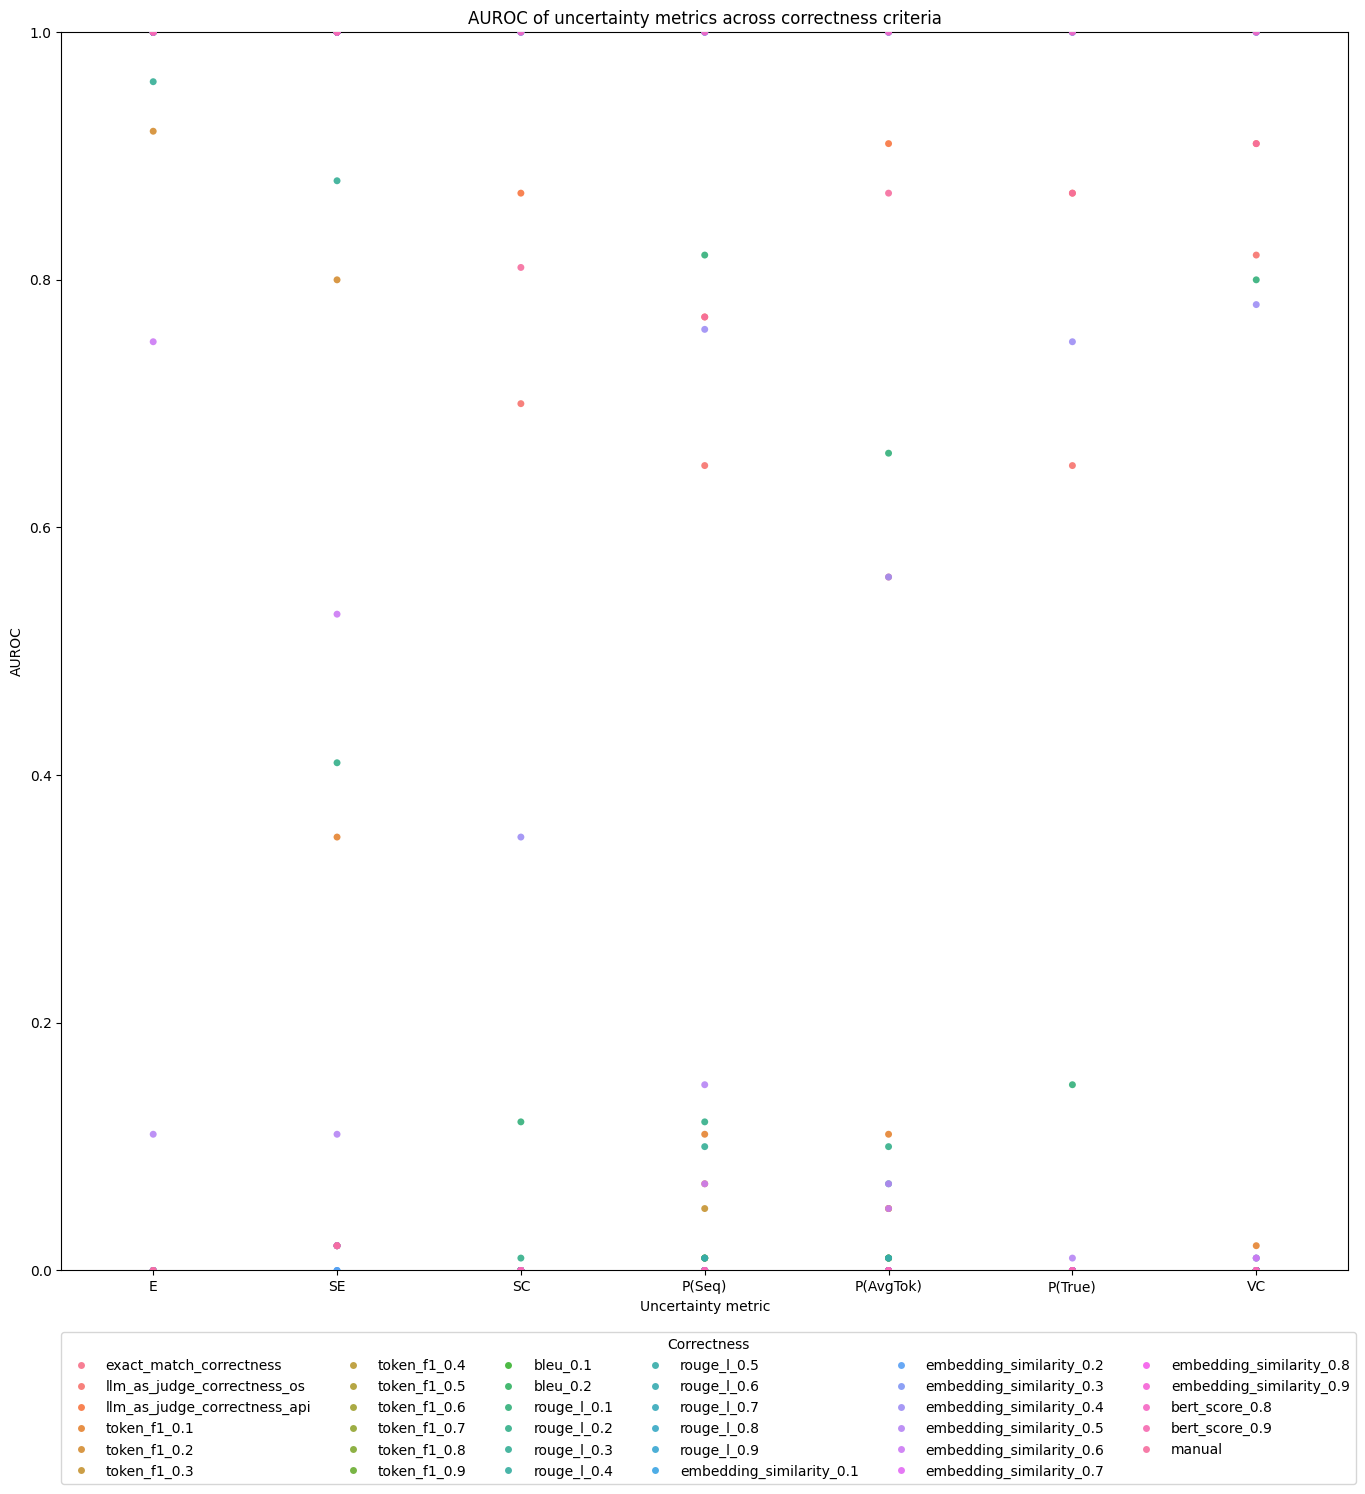

In [21]:
# Visualise AUROC of uncertainty metrics across correctness criteria

rows = []
for correctness_name, values in aurocs.items():
    for unc_name, auroc_val in values["uncertainty_metrics"].items():
        rows.append(
            {
                "correctness": correctness_name,
                "uncertainty_metric": unc_name,
                "auroc": auroc_val,
            }
        )

# Add ACTUAL uncertainty scores based on human-labelled correctness
rows.extend(
    [
        {"correctness": "manual", "uncertainty_metric": "entropy_scores", "auroc": actual_entropy},
        {"correctness": "manual", "uncertainty_metric": "semantic_entropy_scores", "auroc": actual_semantic_entropy},
        {"correctness": "manual", "uncertainty_metric": "semantic_confidence_scores", "auroc": actual_semantic_confidence},
        {"correctness": "manual", "uncertainty_metric": "prob_sequence_scores", "auroc": actual_prob_sequence},
        {"correctness": "manual", "uncertainty_metric": "prob_avg_token_scores", "auroc": actual_prob_avg_token},
        {"correctness": "manual", "uncertainty_metric": "prob_true_scores", "auroc": actual_prob_true},
        {"correctness": "manual", "uncertainty_metric": "verbalised_confidence_scores", "auroc": actual_verbalised_confidence},
    ]
)

auroc_df = pd.DataFrame(rows)

plt.figure(figsize=(15, 15))
# Use dots on the same vertical line for each uncertainty metric
sns.stripplot(
    data=auroc_df,
    x="uncertainty_metric",
    y="auroc",
    hue="correctness",
    dodge=False,  # all on same vertical line
    jitter=False,
    alpha=0.9,
)


# Move legend outside and make it 4 columns
plt.legend(
    title="Correctness",
    bbox_to_anchor=(0.0, -0.05),
    loc="upper left",
    borderaxespad=0.0,
    ncol=6,
)

# plt.xticks(rotation=0, ticks=["E", "SE", "SC", "P(Seq)", "P(AvgTok)", "P(True)", "VC"])
plt.gca().set_xticks(ticks=range(7), labels=["E", "SE", "SC", "P(Seq)", "P(AvgTok)", "P(True)", "VC"])
plt.ylim(0, 1)
plt.xlabel("Uncertainty metric")
plt.ylabel("AUROC")
plt.title("AUROC of uncertainty metrics across correctness criteria")
plt.tight_layout()
plt.show()

In [22]:
bins = np.linspace(0, 1, 11)
bins_f1 = {}
for k in aurocs.keys():
    f1 = aurocs[k]["metrics"]["f1"]
    f1_bin = math.floor(f1 * 10) / 10
    try:
        bins_f1[f"{f1_bin}-{f1_bin+0.1}"].append(k)
    except:
        bins_f1[f"{f1_bin}-{f1_bin+0.1}"] = [k]

visual_correctness_criteria = []
for k in bins_f1.keys():
    visual_correctness_criteria.append(random.sample(bins_f1[k], 1)[0])

In [23]:
filtered_aurocs = {}
for k in aurocs.keys():
    if k in visual_correctness_criteria:
        filtered_aurocs[k] = aurocs[k]

In [24]:
unique_correctness = auroc_df["correctness"].unique()

dict_f1_filtered = {}
pairs = []
for corr in unique_correctness:
    if corr == "manual":
        dict_f1_filtered[corr] = 1
        pairs.append((corr, 1))
    else:
        dict_f1_filtered[corr] = round(aurocs[corr]["metrics"]["f1"],2)
        pairs.append((corr, round(aurocs[corr]["metrics"]["f1"],2)))

In [25]:
pairs.sort(key=lambda x: x[1], reverse=False)

In [26]:
unique_correctness = np.array([x[0] for x in pairs])

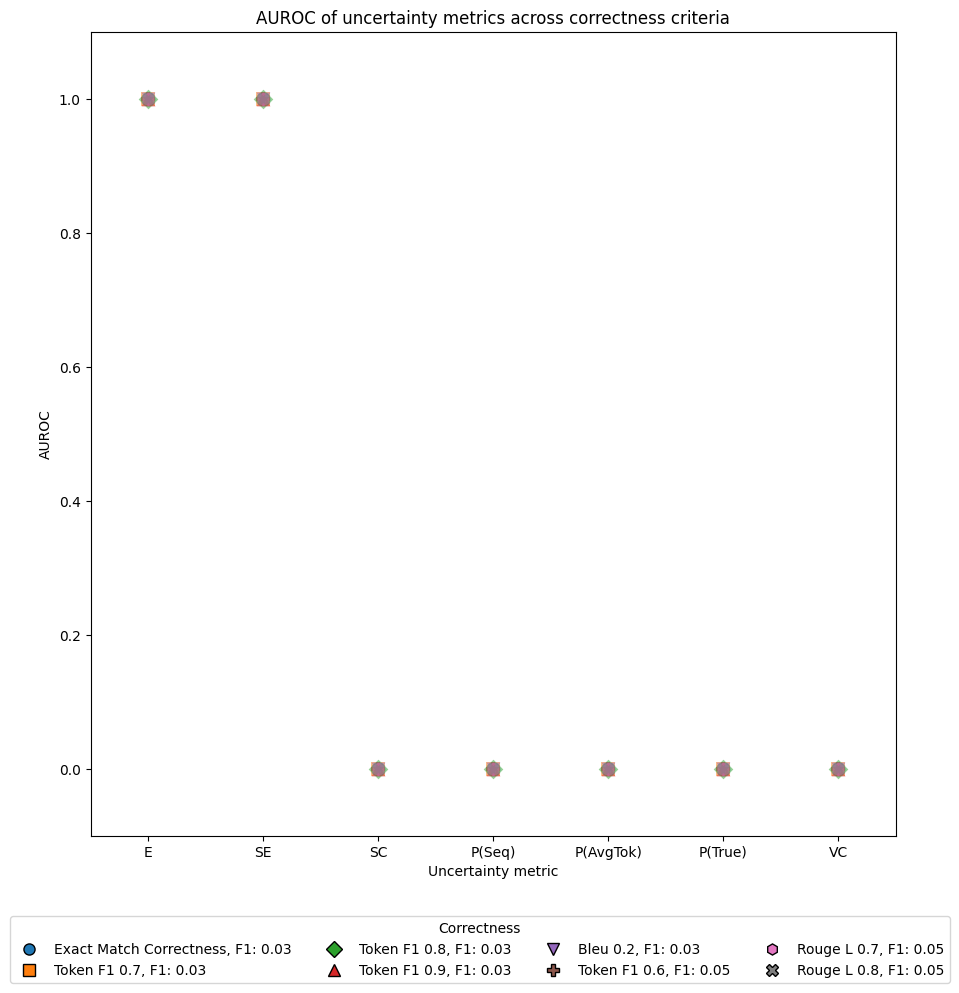

In [27]:
plt.figure(figsize=(10, 10))

# Define a marker for each correctness criterion
markers = ["o", "s", "D", "^", "v", "P", "h", "X"]  # extend if you have more groups
# unique_correctness = auroc_df["correctness"].unique()

for marker, corr in zip(markers, unique_correctness):
    subset = auroc_df[auroc_df["correctness"] == corr]
    if corr == "manual":
        sns.stripplot(
        data=subset,
        x="uncertainty_metric",
        y="auroc",
        label=f"{' '.join(corr.split('_')).title()}",
        dodge=True,
        jitter=True,
        alpha=0.5,
        marker=marker,
        size=25
    )
    else:
        sns.stripplot(
        data=subset,
        x="uncertainty_metric",
        y="auroc",
        label=f"{' '.join(corr.split('_')).title()}",
        dodge=False,
        jitter=False,
        alpha=0.5,
        marker=marker,
        size=10)

plt.ylim(-0.1, 1.1)
plt.xlabel("Uncertainty metric")
plt.ylabel("AUROC")
plt.title("AUROC of uncertainty metrics across correctness criteria")

from matplotlib.lines import Line2D
import seaborn as sns

# Same palette order as seaborn uses for the plot
palette = sns.color_palette(n_colors=len(unique_correctness))

legend_elements = [
    Line2D(
        [0],
        [0],
        marker=marker,
        color="none",
        markerfacecolor=color,
        markeredgecolor="black",
        markersize=8,
        linestyle="None",
        label=f"{' '.join(corr.split('_')).title()}, F1: {dict_f1_filtered[corr]}",
    )
    for (marker, corr), color in zip(zip(markers, unique_correctness), palette)
]

plt.legend(
    handles=legend_elements,
    title="Correctness",
    bbox_to_anchor=(-0.1, -0.1),
    loc="upper left",
    borderaxespad=0.0,
    ncol=4
)

plt.gca().set_xticks(ticks=range(7), labels=["E", "SE", "SC", "P(Seq)", "P(AvgTok)", "P(True)", "VC"], rotation=0)

plt.tight_layout()
plt.show()

In [28]:
UNCERTAINTY_LABELS = {
    "entropy_scores": "Ent.",
    "semantic_entropy_scores": "Sem. entropy",
    "semantic_confidence_scores": "Sem. conf.",
    "prob_sequence_scores": "P(seq.)",
    "prob_avg_token_scores": "N.P(seq.)",
    "prob_true_scores": "P(true)",
    "verbalised_confidence_scores": "Verb. conf.",
}


def format_correctness_label(name):
    if name == "manual":
        return "Human labels"
    if name == "exact_match_correctness":
        return "Exact match"
    if name == "llm_as_judge_correctness_os":
        return "LLM judge (Llama 8B)"
    if name == "llm_as_judge_correctness_api":
        return "LLM judge (GPT)"
    if name == "llm_as_judge_correctness":
        return "LLM judge"
    if name.startswith("token_f1_"):
        return f"Token F1 (τ={name.removeprefix('token_f1_')})"
    if name.startswith("bleu_"):
        return f"BLEU (τ={name.removeprefix('bleu_')})"
    if name.startswith("rouge_l_"):
        return f"ROUGE-L (τ={name.removeprefix('rouge_l_')})"
    if name.startswith("embedding_similarity_"):
        return f"Emb. sim. (τ={name.removeprefix('embedding_similarity_')})"
    if name.startswith("bert_score_"):
        return f"BERTScore (τ={name.removeprefix('bert_score_')})"
    return name.replace("_", " ").title()


def label_heatmap_data(data):
    labelled = data.copy()
    labelled.index = [
        f"{format_correctness_label(idx)} · F1={dict_f1_filtered[idx]:.2f}"
        for idx in labelled.index
    ]
    labelled.columns = [UNCERTAINTY_LABELS.get(col, col) for col in labelled.columns]
    return labelled


def style_heatmap_axes(ax, xlabel, ylabel, title):
    ax.set_title(title, fontsize=25, pad=12)
    ax.set_xlabel(xlabel, fontsize=25, labelpad=10)
    ax.set_ylabel(ylabel, fontsize=25, labelpad=10)
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        rotation_mode="anchor",
        fontsize=25,
    )
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=25)
    ax.tick_params(axis="both", length=0)

In [29]:
auroc_df["auroc_rank"] = (
    auroc_df.groupby("correctness")["auroc"]
      .rank(method="first", ascending=False)
      .astype(int)
)

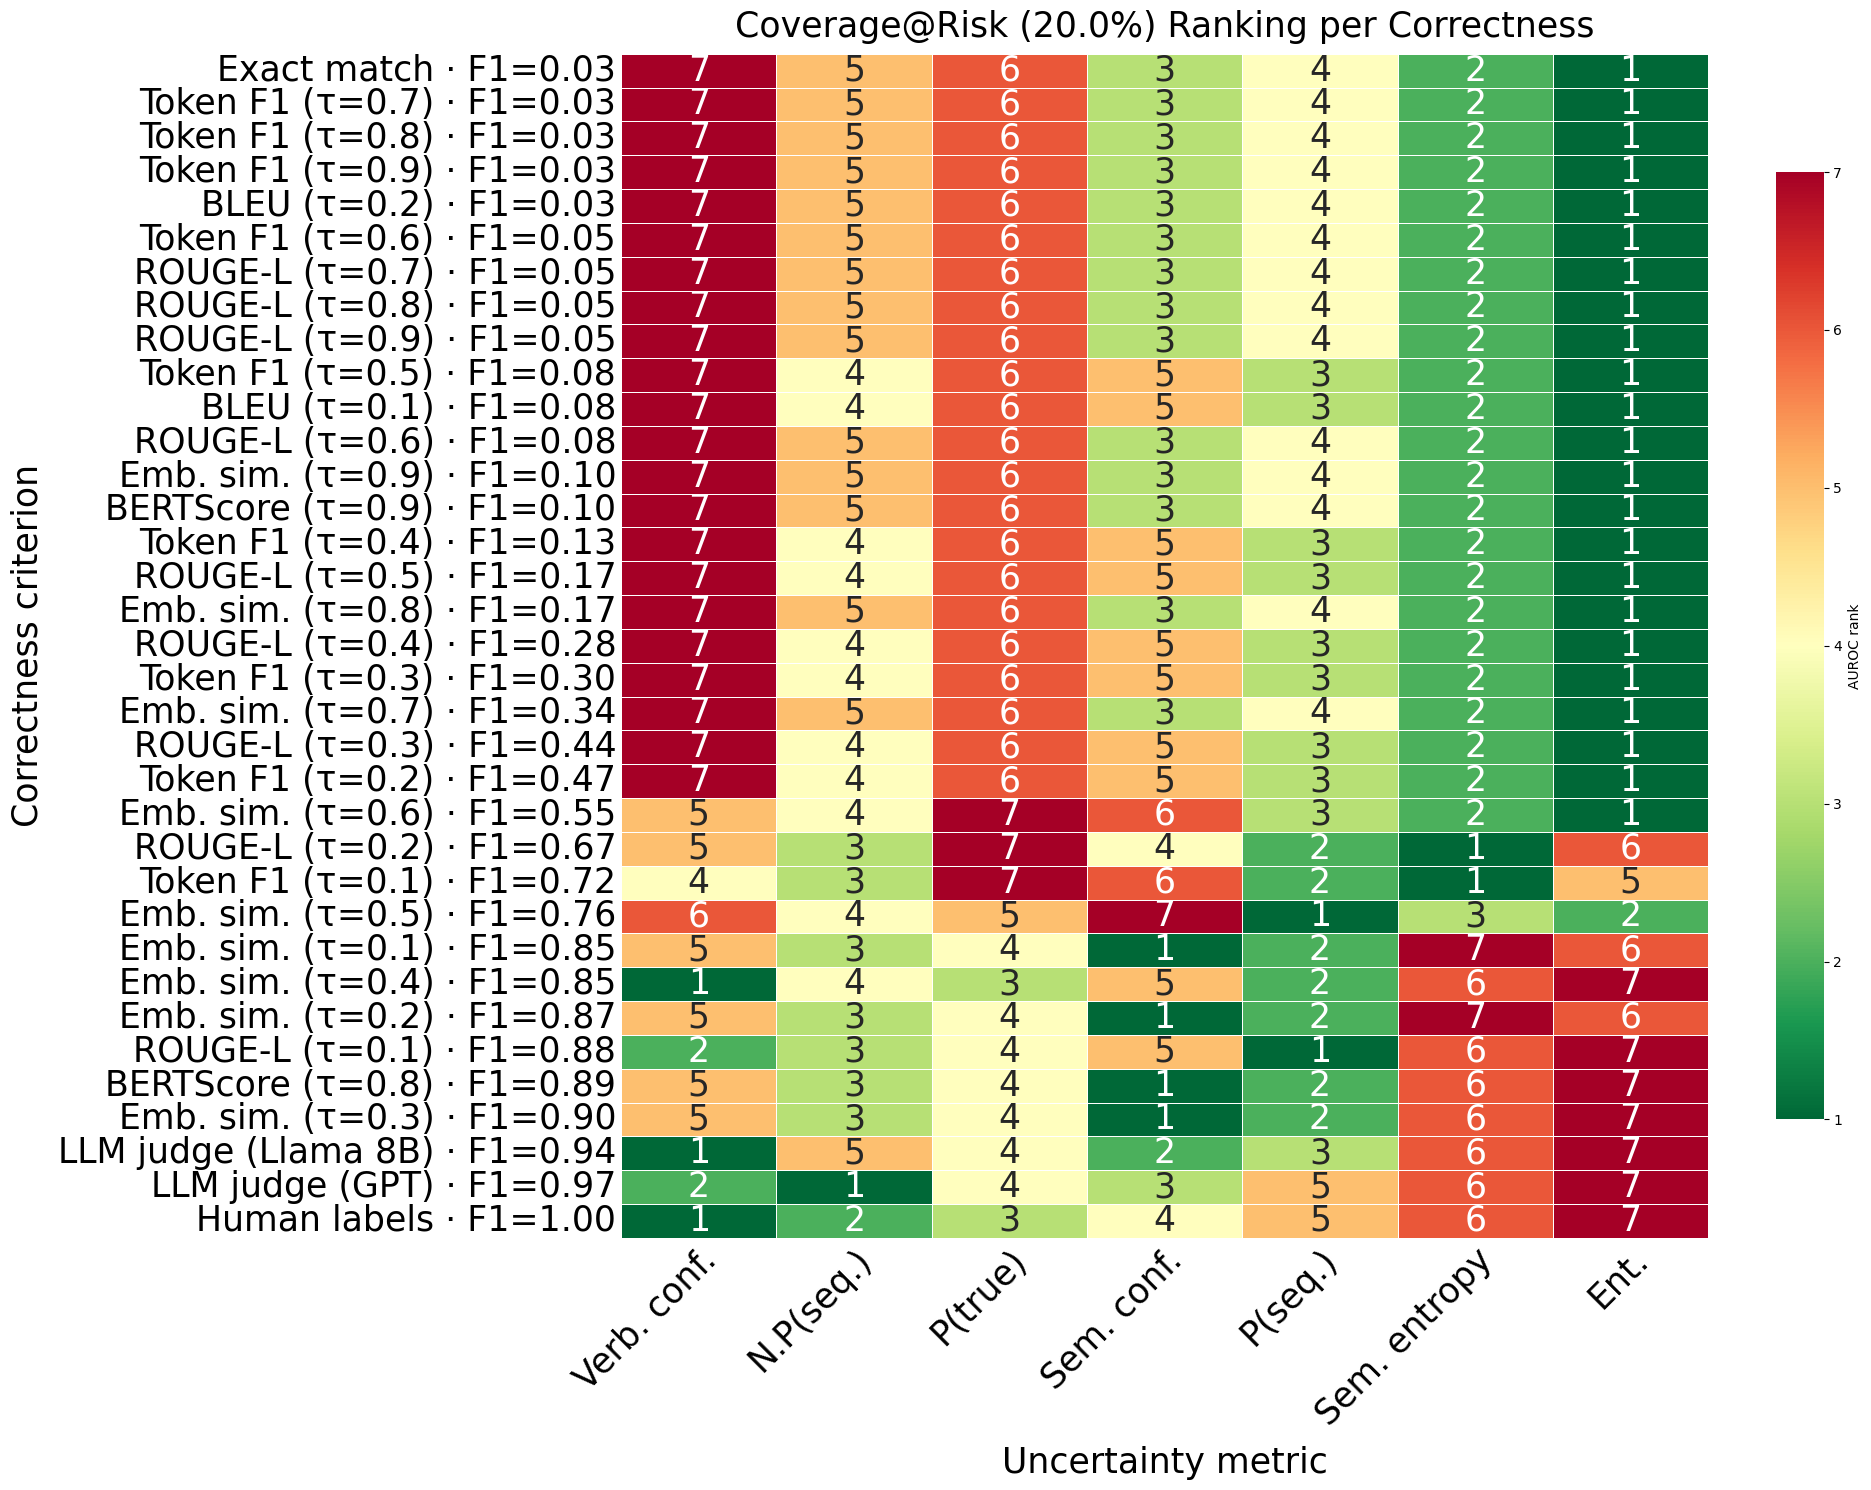

In [ ]:
heatmap_data = auroc_df.pivot(
    index="correctness",
    columns="uncertainty_metric",
    values="auroc_rank"
)
heatmap_data = heatmap_data.reindex(unique_correctness)
sorted_cols = heatmap_data.loc["manual"].sort_values().index
heatmap_data = heatmap_data[sorted_cols]
heatmap_data = label_heatmap_data(heatmap_data)

plt.figure(figsize=(20, 15))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    annot_kws={"size": 25},
    cmap="RdYlGn_r",  # rank 1 = green, rank 7 = red
    vmin=1,
    vmax=7,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "AUROC rank", "shrink": 0.8},
)

style_heatmap_axes(
    ax,
    xlabel="Uncertainty metric",
    ylabel="Correctness criterion",
    title=f"Coverage@Risk ({target_risk*100}%) Ranking per Correctness",
)

plt.tight_layout()
plt.savefig(
    f"/auroc_eval/results/plots/cov_at_risk_{target_risk}_ranking_per_correctness_{model_name}.pdf",
    bbox_inches="tight",
)
plt.show()

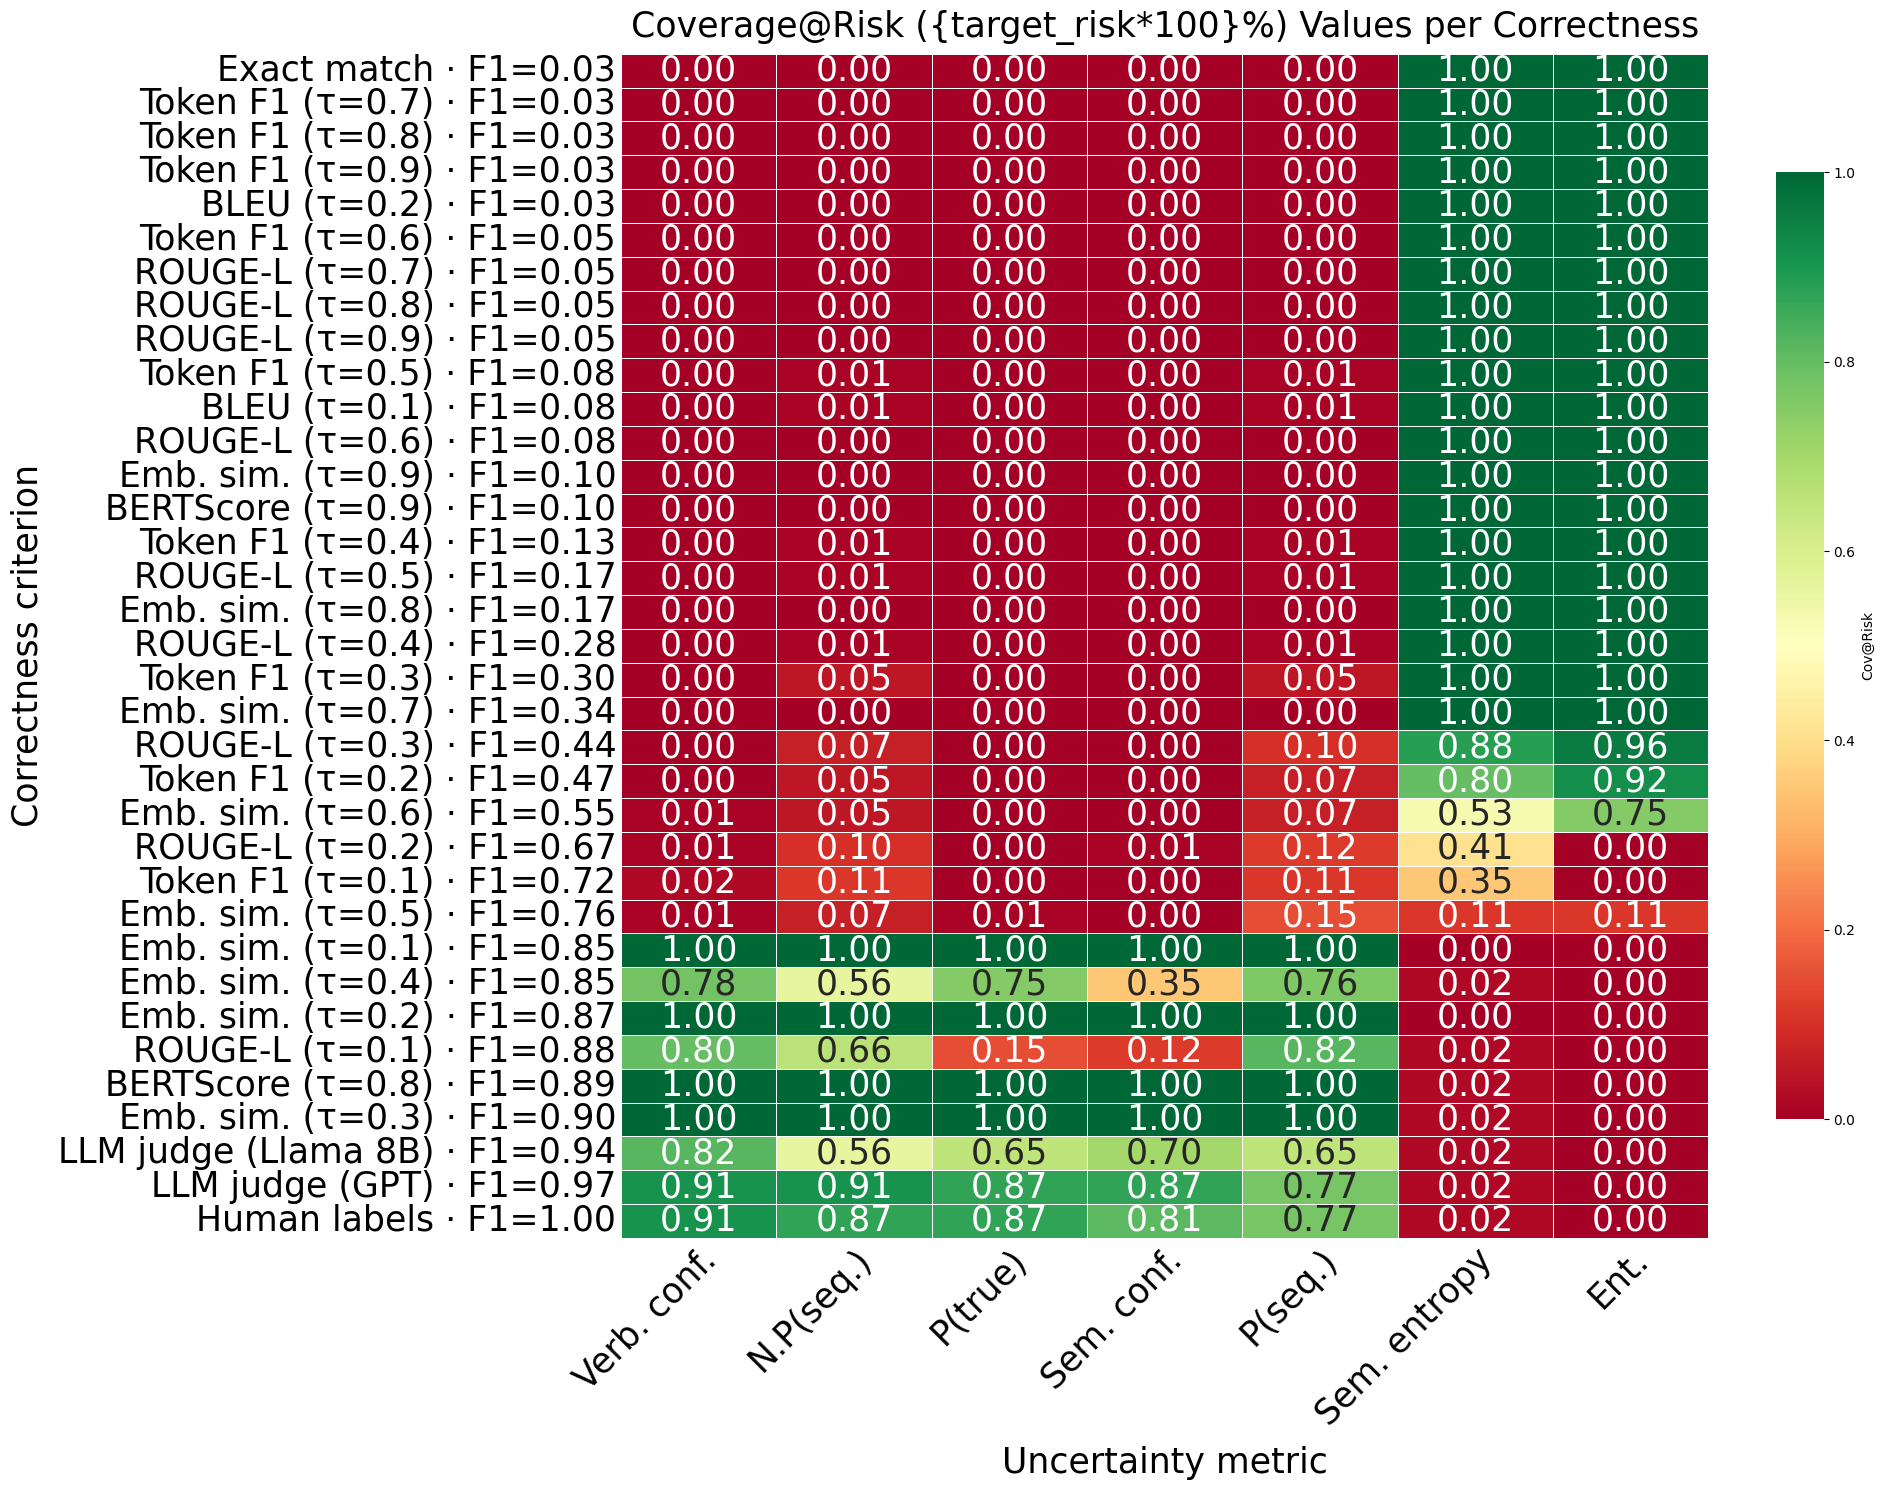

In [ ]:
heatmap_data = auroc_df.pivot(
    index="correctness",
    columns="uncertainty_metric",
    values="auroc"
)
heatmap_data = heatmap_data.reindex(unique_correctness)
sorted_cols = heatmap_data.loc["manual"].sort_values(ascending=False).index
heatmap_data = heatmap_data[sorted_cols]
heatmap_data = label_heatmap_data(heatmap_data)

plt.figure(figsize=(20, 15))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 25},
    cmap="RdYlGn",  # 0 = red, 1 = green
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Cov@Risk", "shrink": 0.8},
)

style_heatmap_axes(
    ax,
    xlabel="Uncertainty metric",
    ylabel="Correctness criterion",
    title="Coverage@Risk ({target_risk*100}%) Values per Correctness",
)

plt.tight_layout()
plt.savefig(
    f"/auroc_eval/results/plots/cov_at_risk_{target_risk}_values_per_correctness_{model_name}.pdf",
    bbox_inches="tight",
)
plt.show()

In [33]:
# auroc_df[auroc_df["correctness"] == "manual"]

manual_map = (
    auroc_df[auroc_df["correctness"] == "manual"]
    .set_index("uncertainty_metric")["auroc"]
)

auroc_df["auroc_manual"] = auroc_df["uncertainty_metric"].map(manual_map)
auroc_df["auroc_diff"] = auroc_df["auroc"] - auroc_df["auroc_manual"]

In [34]:
auroc_df_filtered = auroc_df[auroc_df["correctness"] != "manual"]

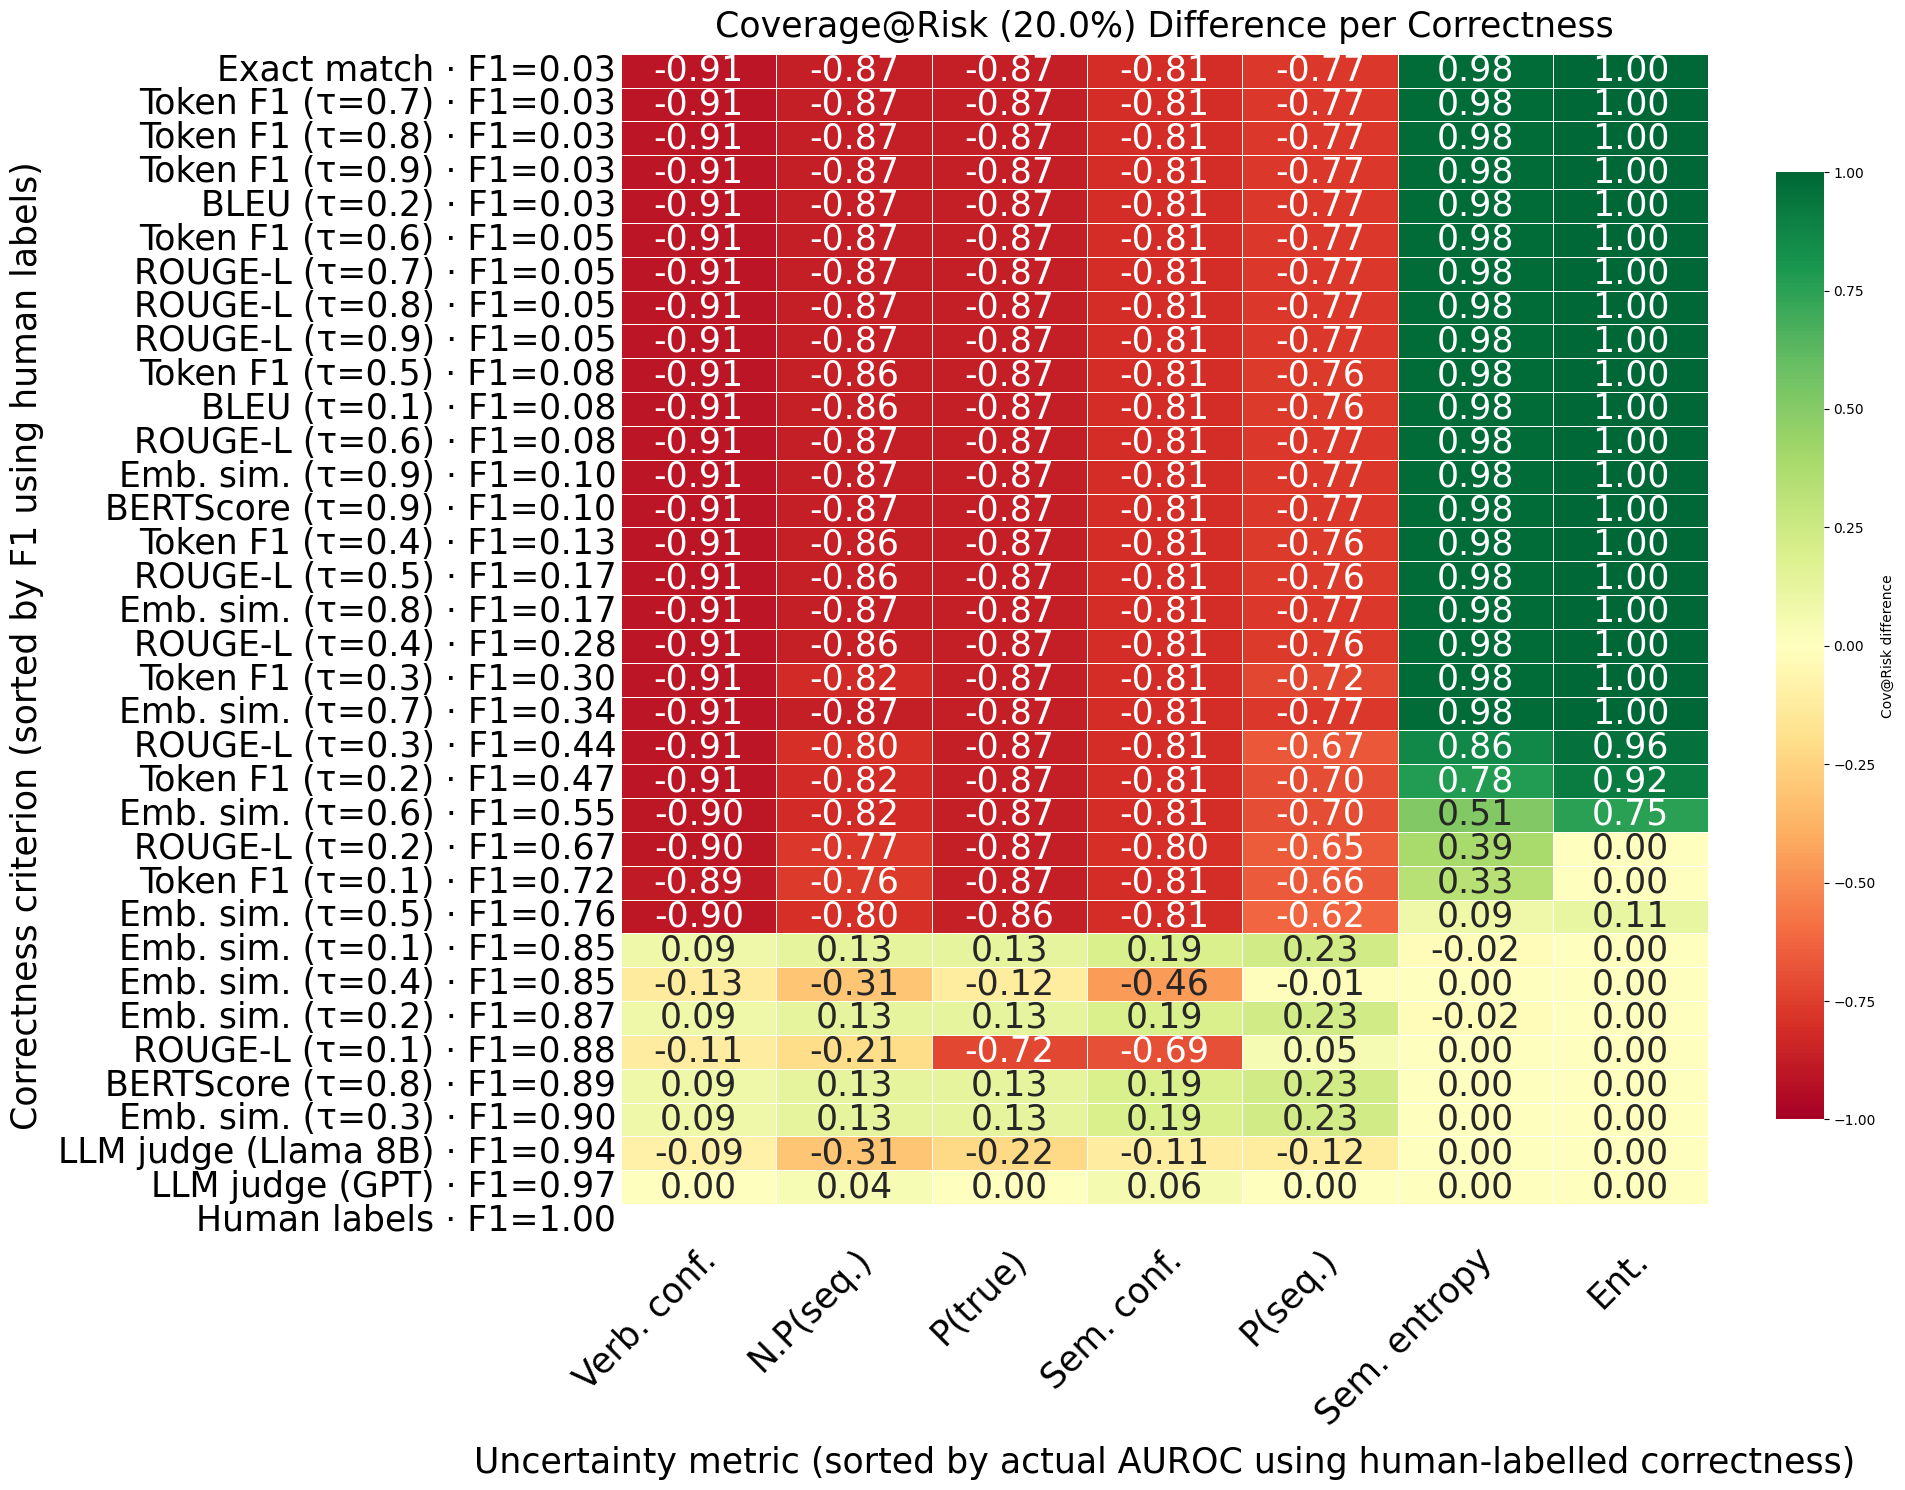

In [ ]:
heatmap_data_diff = auroc_df_filtered.pivot(
    index="correctness",
    columns="uncertainty_metric",
    values="auroc_diff"
)
heatmap_data_diff = heatmap_data_diff.reindex(unique_correctness)
heatmap_data_diff = heatmap_data_diff[sorted_cols]
heatmap_data_diff = label_heatmap_data(heatmap_data_diff)

plt.figure(figsize=(20, 15))

ax = sns.heatmap(
    heatmap_data_diff,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 25},
    cmap="RdYlGn",  # -1 = red, 1 = green
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Cov@Risk difference", "shrink": 0.8},
)

style_heatmap_axes(
    ax,
    xlabel="Uncertainty metric (sorted by actual AUROC using human-labelled correctness)",
    ylabel="Correctness criterion (sorted by F1 using human labels)",
    title=f"Coverage@Risk ({target_risk*100}%) Difference per Correctness",
)

plt.tight_layout()
plt.savefig(
    f"/auroc_eval/results/plots/cov_at_risk_{target_risk}_diff_per_correctness_{model_name}.pdf",
    bbox_inches="tight",
)
plt.show()

#### 2) Risk at fixed coverage %

In [36]:
print("Actual risk Scores")
actual_entropy =  risk_at_fixed_coverage(entropy_scores, [not x for x in correctness_manual], target_coverage)#uncertainty - not confidence -> need to switch correctness sign
actual_semantic_entropy = risk_at_fixed_coverage(semantic_entropy_scores, [not x for x in correctness_manual], target_coverage)#uncertainty - not confidence -> need to switch correctness sign
actual_semantic_confidence = risk_at_fixed_coverage(semantic_confidence_scores, correctness_manual, target_coverage)
actual_prob_sequence = risk_at_fixed_coverage(prob_sequence_scores, correctness_manual, target_coverage)
actual_prob_avg_token = risk_at_fixed_coverage(prob_avg_token_scores, correctness_manual, target_coverage)
actual_prob_true = risk_at_fixed_coverage(prob_true_scores, correctness_manual, target_coverage)
actual_verbalised_confidence = risk_at_fixed_coverage([float(x.replace("Confidence: ", "")) for x in verbalised_confidence_scores], correctness_manual, target_coverage)

Actual risk Scores


In [37]:
if errors == "automated":
    aurocs = {}

    for c in correctness.keys():
        if len(set(correctness[c])) == 1:
            continue
        else:
            aurocs[c] = {} 
            aurocs[c]["metrics"] = {}
            aurocs[c]["metrics"]["acc"] = accuracy_score(correctness_manual, correctness[c])
            aurocs[c]["metrics"]["prec"] = precision_score(correctness_manual, correctness[c])
            aurocs[c]["metrics"]["rec"] = recall_score(correctness_manual, correctness[c])
            aurocs[c]["metrics"]["f1"] = f1_score(correctness_manual, correctness[c])
            aurocs[c]["metrics"]["conf_matrix"] = confusion_matrix(correctness_manual, correctness[c])

            aurocs[c]["uncertainty_metrics"] = {}
            for u in unc_scores.keys():
                if "entropy" in u:
                    aurocs[c]["uncertainty_metrics"][u] = risk_at_fixed_coverage(unc_scores[u], [not x for x in correctness[c]], target_coverage)
                else:
                    aurocs[c]["uncertainty_metrics"][u] = risk_at_fixed_coverage(unc_scores[u], correctness[c], target_coverage)
elif errors == "random":
    aurocs = {}
    error_rate = np.arange(0.1, 1, 0.1)


    for e in error_rate:
        switch_indices = np.random.randint(low=0, high=99, size=round(e*100), dtype=int)
        correctness = [abs(1-x)  if i in switch_indices else x for i,x in enumerate(correctness_manual)]
        if len(set(correctness)) == 1:
            continue
        else:
            aurocs["error_rate_"+str(e)[:3]] = {} 
            aurocs["error_rate_"+str(e)[:3]]["metrics"] = {}
            aurocs["error_rate_"+str(e)[:3]]["metrics"]["acc"] = accuracy_score(correctness_manual, correctness)
            aurocs["error_rate_"+str(e)[:3]]["metrics"]["prec"] = precision_score(correctness_manual, correctness)
            aurocs["error_rate_"+str(e)[:3]]["metrics"]["rec"] = recall_score(correctness_manual, correctness)
            aurocs["error_rate_"+str(e)[:3]]["metrics"]["f1"] = f1_score(correctness_manual, correctness)
            aurocs["error_rate_"+str(e)[:3]]["metrics"]["conf_matrix"] = confusion_matrix(correctness_manual, correctness)

            aurocs["error_rate_"+str(e)[:3]]["uncertainty_metrics"] = {}
            for u in unc_scores.keys():
                if "entropy" in u:
                    aurocs["error_rate_"+str(e)[:3]]["uncertainty_metrics"][u] = risk_at_fixed_coverage(unc_scores[u], [not x for x in correctness], target_coverage)
                else:
                    aurocs["error_rate_"+str(e)[:3]]["uncertainty_metrics"][u] = risk_at_fixed_coverage(unc_scores[u], correctness, target_coverage)
else:
    raise ValueError("Invalid error type")


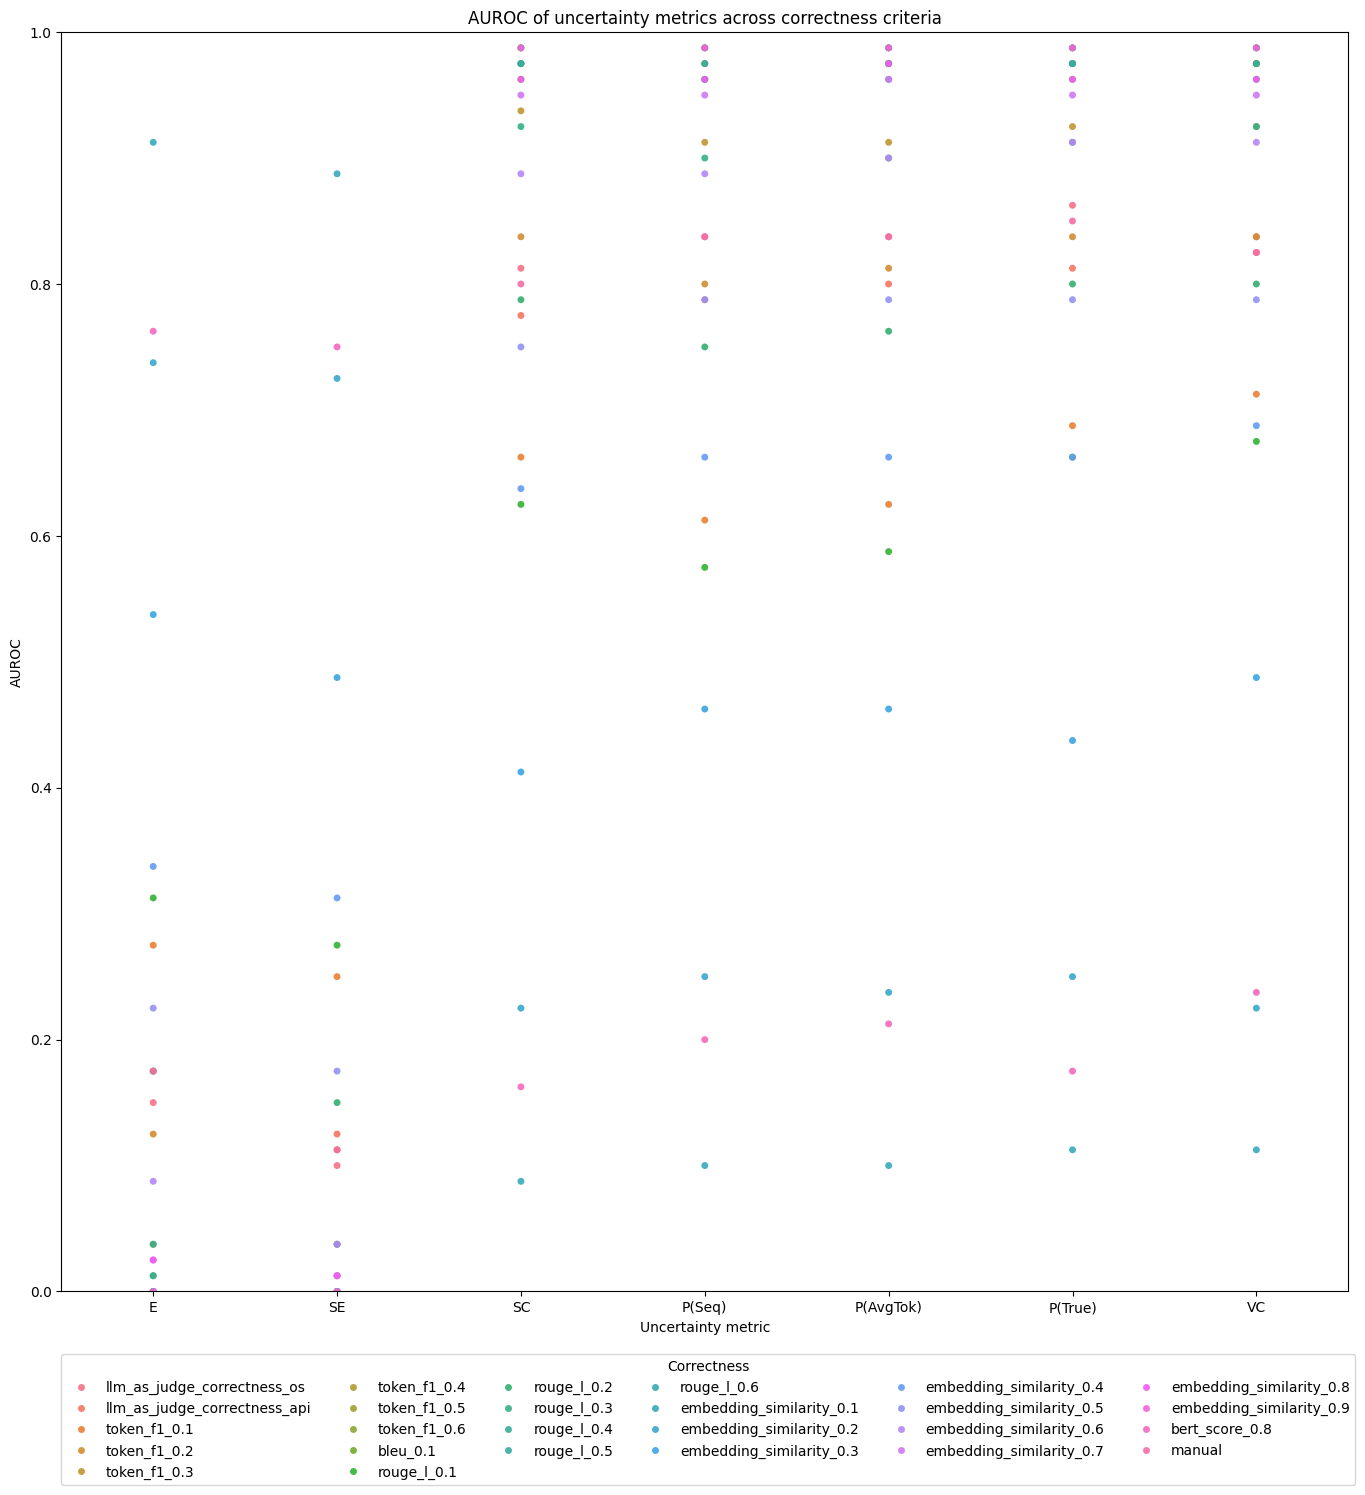

In [276]:
# Visualise AUROC of uncertainty metrics across correctness criteria

rows = []
for correctness_name, values in aurocs.items():
    for unc_name, auroc_val in values["uncertainty_metrics"].items():
        rows.append(
            {
                "correctness": correctness_name,
                "uncertainty_metric": unc_name,
                "auroc": auroc_val,
            }
        )

# Add ACTUAL uncertainty scores based on human-labelled correctness
rows.extend(
    [
        {"correctness": "manual", "uncertainty_metric": "entropy_scores", "auroc": actual_entropy},
        {"correctness": "manual", "uncertainty_metric": "semantic_entropy_scores", "auroc": actual_semantic_entropy},
        {"correctness": "manual", "uncertainty_metric": "semantic_confidence_scores", "auroc": actual_semantic_confidence},
        {"correctness": "manual", "uncertainty_metric": "prob_sequence_scores", "auroc": actual_prob_sequence},
        {"correctness": "manual", "uncertainty_metric": "prob_avg_token_scores", "auroc": actual_prob_avg_token},
        {"correctness": "manual", "uncertainty_metric": "prob_true_scores", "auroc": actual_prob_true},
        {"correctness": "manual", "uncertainty_metric": "verbalised_confidence_scores", "auroc": actual_verbalised_confidence},
    ]
)

auroc_df = pd.DataFrame(rows)

plt.figure(figsize=(15, 15))
# Use dots on the same vertical line for each uncertainty metric
sns.stripplot(
    data=auroc_df,
    x="uncertainty_metric",
    y="auroc",
    hue="correctness",
    dodge=False,  # all on same vertical line
    jitter=False,
    alpha=0.9,
)


# Move legend outside and make it 4 columns
plt.legend(
    title="Correctness",
    bbox_to_anchor=(0.0, -0.05),
    loc="upper left",
    borderaxespad=0.0,
    ncol=6,
)

# plt.xticks(rotation=0, ticks=["E", "SE", "SC", "P(Seq)", "P(AvgTok)", "P(True)", "VC"])
plt.gca().set_xticks(ticks=range(7), labels=["E", "SE", "SC", "P(Seq)", "P(AvgTok)", "P(True)", "VC"])
plt.ylim(0, 1)
plt.xlabel("Uncertainty metric")
plt.ylabel("AUROC")
plt.title("AUROC of uncertainty metrics across correctness criteria")
plt.tight_layout()
plt.show()

In [277]:
bins = np.linspace(0, 1, 11)
bins_f1 = {}
for k in aurocs.keys():
    f1 = aurocs[k]["metrics"]["f1"]
    f1_bin = math.floor(f1 * 10) / 10
    try:
        bins_f1[f"{f1_bin}-{f1_bin+0.1}"].append(k)
    except:
        bins_f1[f"{f1_bin}-{f1_bin+0.1}"] = [k]

visual_correctness_criteria = []
for k in bins_f1.keys():
    visual_correctness_criteria.append(random.sample(bins_f1[k], 1)[0])

In [278]:
filtered_aurocs = {}
for k in aurocs.keys():
    if k in visual_correctness_criteria:
        filtered_aurocs[k] = aurocs[k]

In [279]:
unique_correctness = auroc_df["correctness"].unique()

dict_f1_filtered = {}
pairs = []
for corr in unique_correctness:
    if corr == "manual":
        dict_f1_filtered[corr] = 1
        pairs.append((corr, 1))
    else:
        dict_f1_filtered[corr] = round(aurocs[corr]["metrics"]["f1"],2)
        pairs.append((corr, round(aurocs[corr]["metrics"]["f1"],2)))

In [280]:
pairs.sort(key=lambda x: x[1], reverse=False)

In [281]:
unique_correctness = np.array([x[0] for x in pairs])

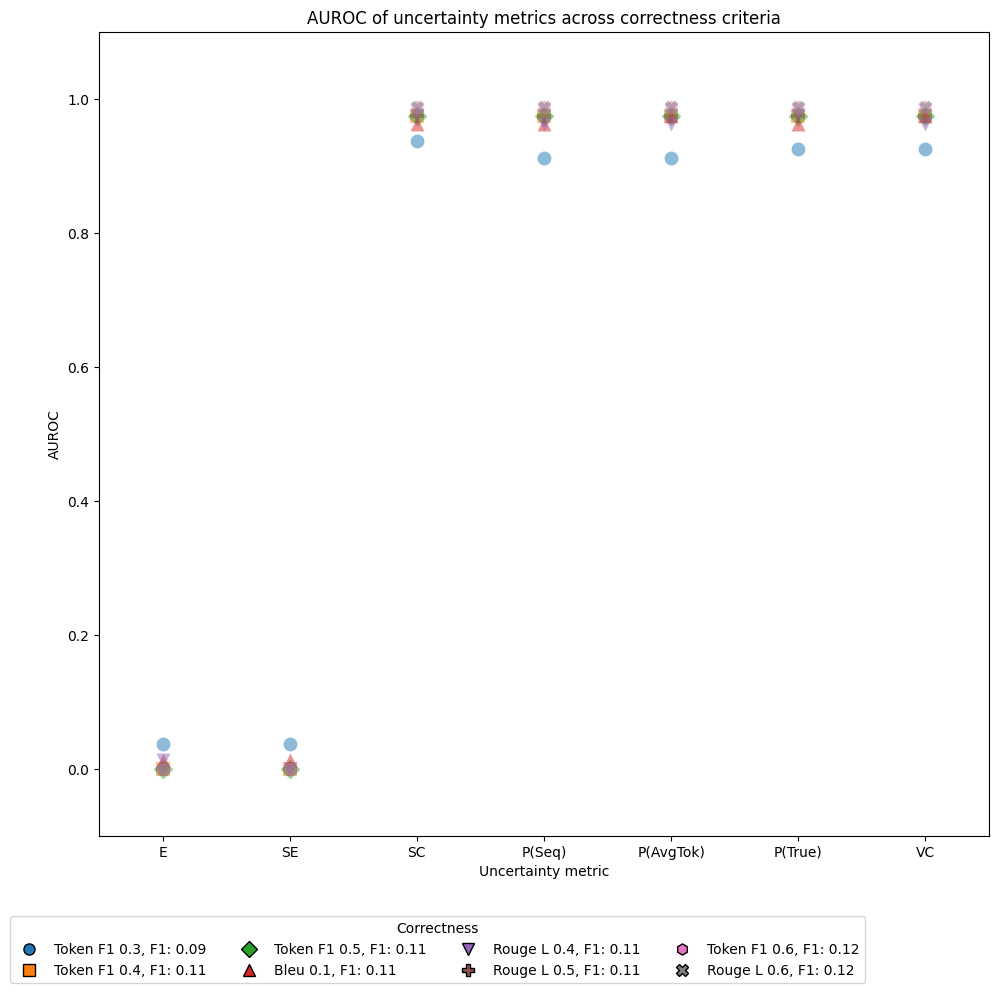

In [282]:
plt.figure(figsize=(10, 10))

# Define a marker for each correctness criterion
markers = ["o", "s", "D", "^", "v", "P", "h", "X"]  # extend if you have more groups
# unique_correctness = auroc_df["correctness"].unique()

for marker, corr in zip(markers, unique_correctness):
    subset = auroc_df[auroc_df["correctness"] == corr]
    if corr == "manual":
        sns.stripplot(
        data=subset,
        x="uncertainty_metric",
        y="auroc",
        label=f"{' '.join(corr.split('_')).title()}",
        dodge=True,
        jitter=True,
        alpha=0.5,
        marker=marker,
        size=25
    )
    else:
        sns.stripplot(
        data=subset,
        x="uncertainty_metric",
        y="auroc",
        label=f"{' '.join(corr.split('_')).title()}",
        dodge=False,
        jitter=False,
        alpha=0.5,
        marker=marker,
        size=10)

plt.ylim(-0.1, 1.1)
plt.xlabel("Uncertainty metric")
plt.ylabel("AUROC")
plt.title("AUROC of uncertainty metrics across correctness criteria")

from matplotlib.lines import Line2D
import seaborn as sns

# Same palette order as seaborn uses for the plot
palette = sns.color_palette(n_colors=len(unique_correctness))

legend_elements = [
    Line2D(
        [0],
        [0],
        marker=marker,
        color="none",
        markerfacecolor=color,
        markeredgecolor="black",
        markersize=8,
        linestyle="None",
        label=f"{' '.join(corr.split('_')).title()}, F1: {dict_f1_filtered[corr]}",
    )
    for (marker, corr), color in zip(zip(markers, unique_correctness), palette)
]

plt.legend(
    handles=legend_elements,
    title="Correctness",
    bbox_to_anchor=(-0.1, -0.1),
    loc="upper left",
    borderaxespad=0.0,
    ncol=4
)

plt.gca().set_xticks(ticks=range(7), labels=["E", "SE", "SC", "P(Seq)", "P(AvgTok)", "P(True)", "VC"], rotation=0)

plt.tight_layout()
plt.show()

In [283]:
auroc_df["auroc_rank"] = (
    auroc_df.groupby("correctness")["auroc"]
      .rank(method="first", ascending=True)
      .astype(int)
)

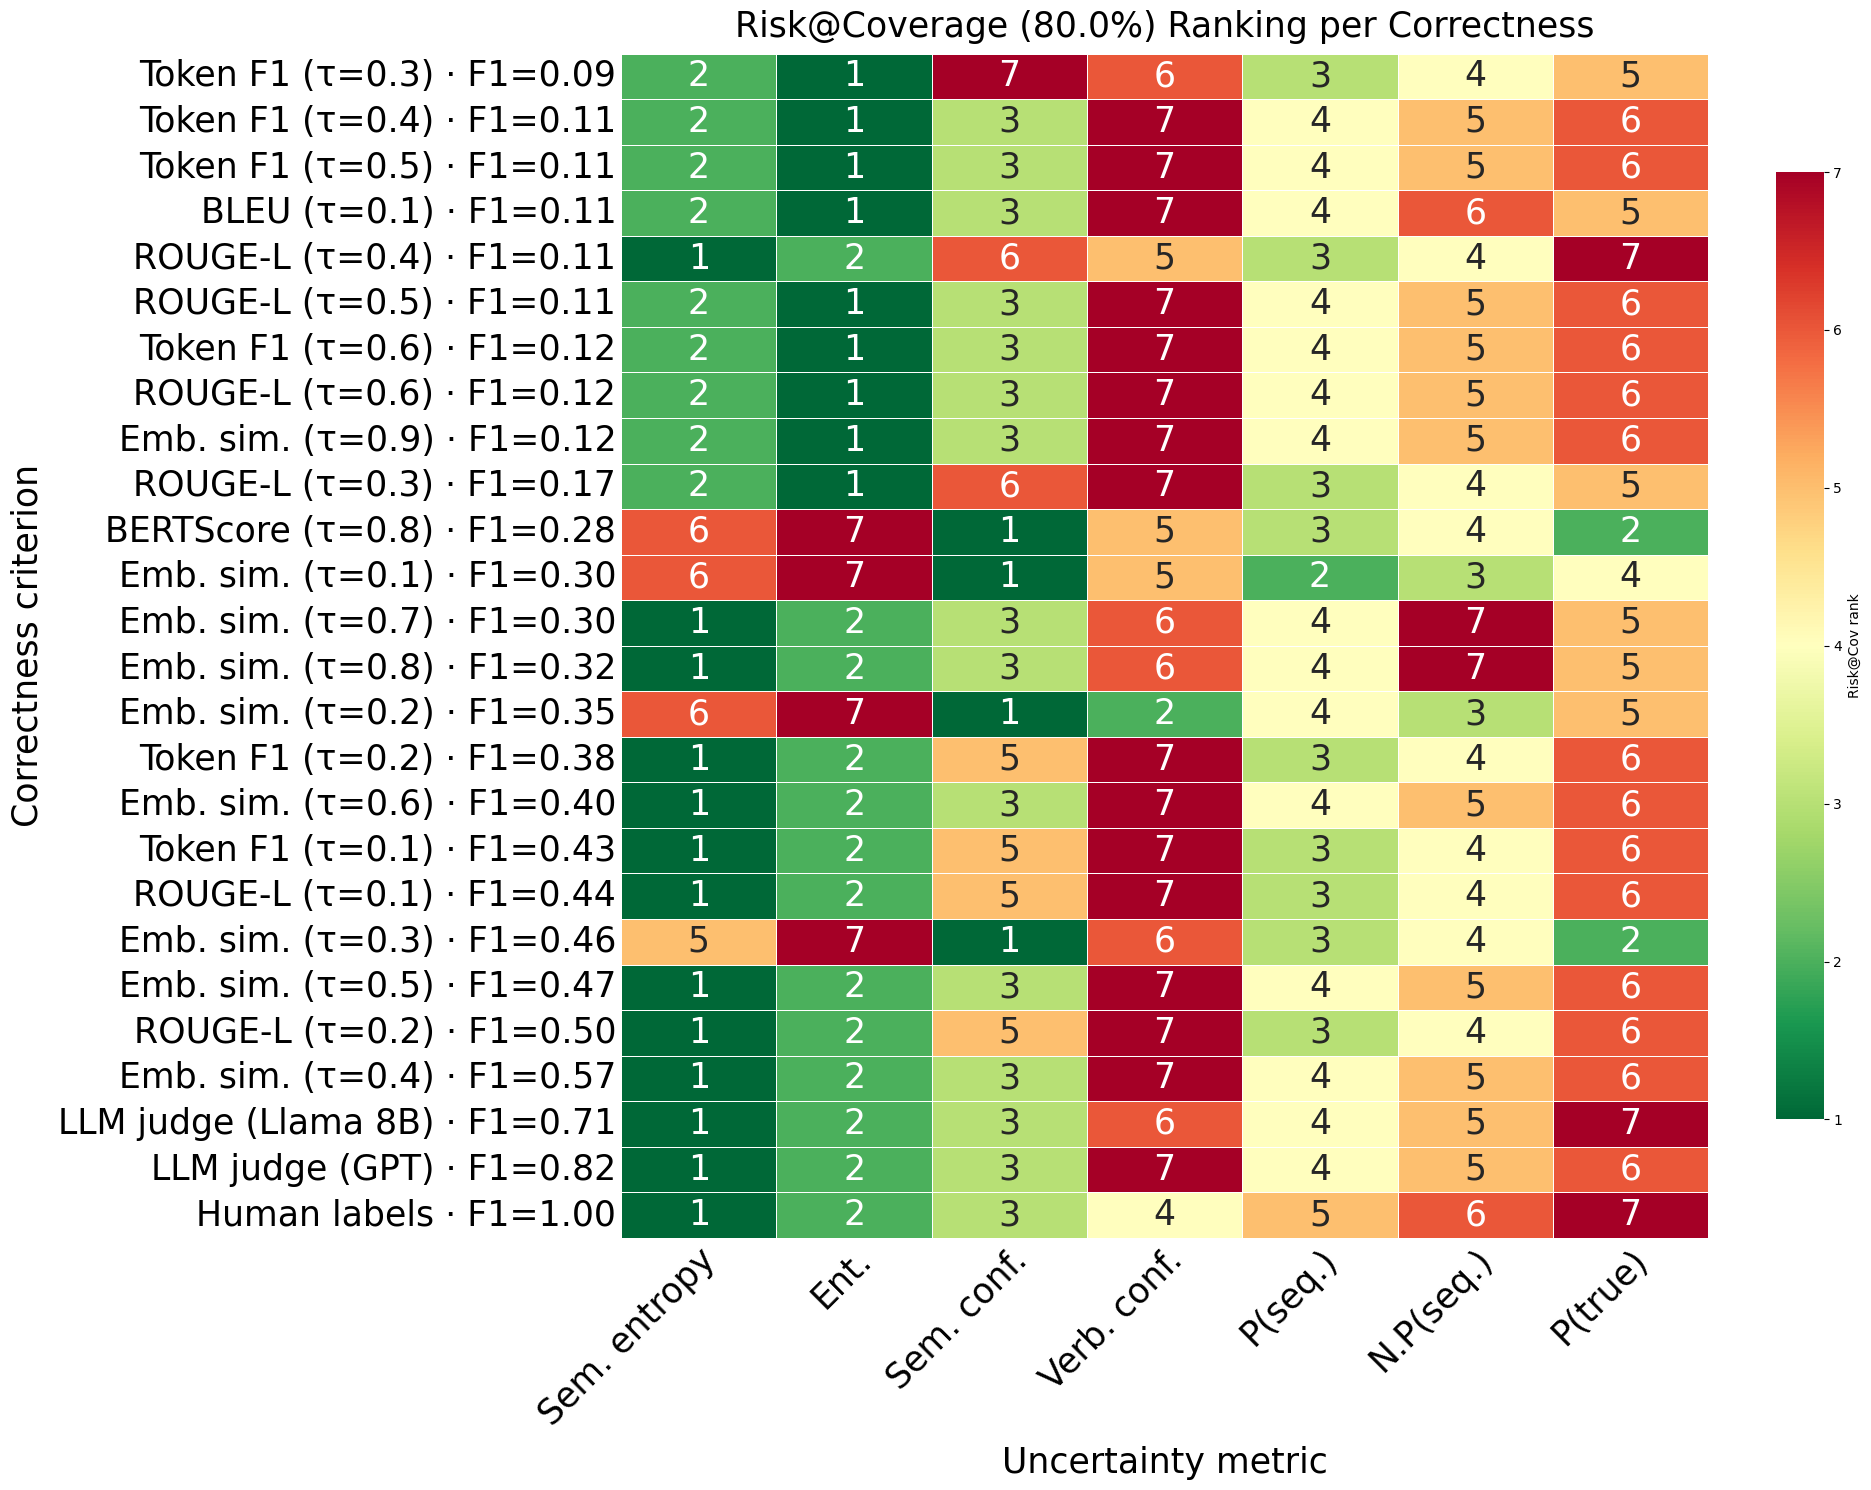

In [ ]:
heatmap_data = auroc_df.pivot(
    index="correctness",
    columns="uncertainty_metric",
    values="auroc_rank"
)
heatmap_data = heatmap_data.reindex(unique_correctness)
sorted_cols = heatmap_data.loc["manual"].sort_values().index
heatmap_data = heatmap_data[sorted_cols]
heatmap_data = label_heatmap_data(heatmap_data)

plt.figure(figsize=(20, 15))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    annot_kws={"size": 25},
    cmap="RdYlGn_r",  # rank 1 = green, rank 7 = red
    vmin=1,
    vmax=7,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Risk@Cov rank", "shrink": 0.8},
)

style_heatmap_axes(
    ax,
    xlabel="Uncertainty metric",
    ylabel="Correctness criterion",
    title=f"Risk@Coverage ({target_coverage*100}%) Ranking per Correctness",
)

plt.tight_layout()
plt.savefig(
    f"/auroc_eval/results/plots/risk_at_coverage_{target_coverage}_ranking_per_correctness_{model_name}.pdf",
    bbox_inches="tight",
)
plt.show()

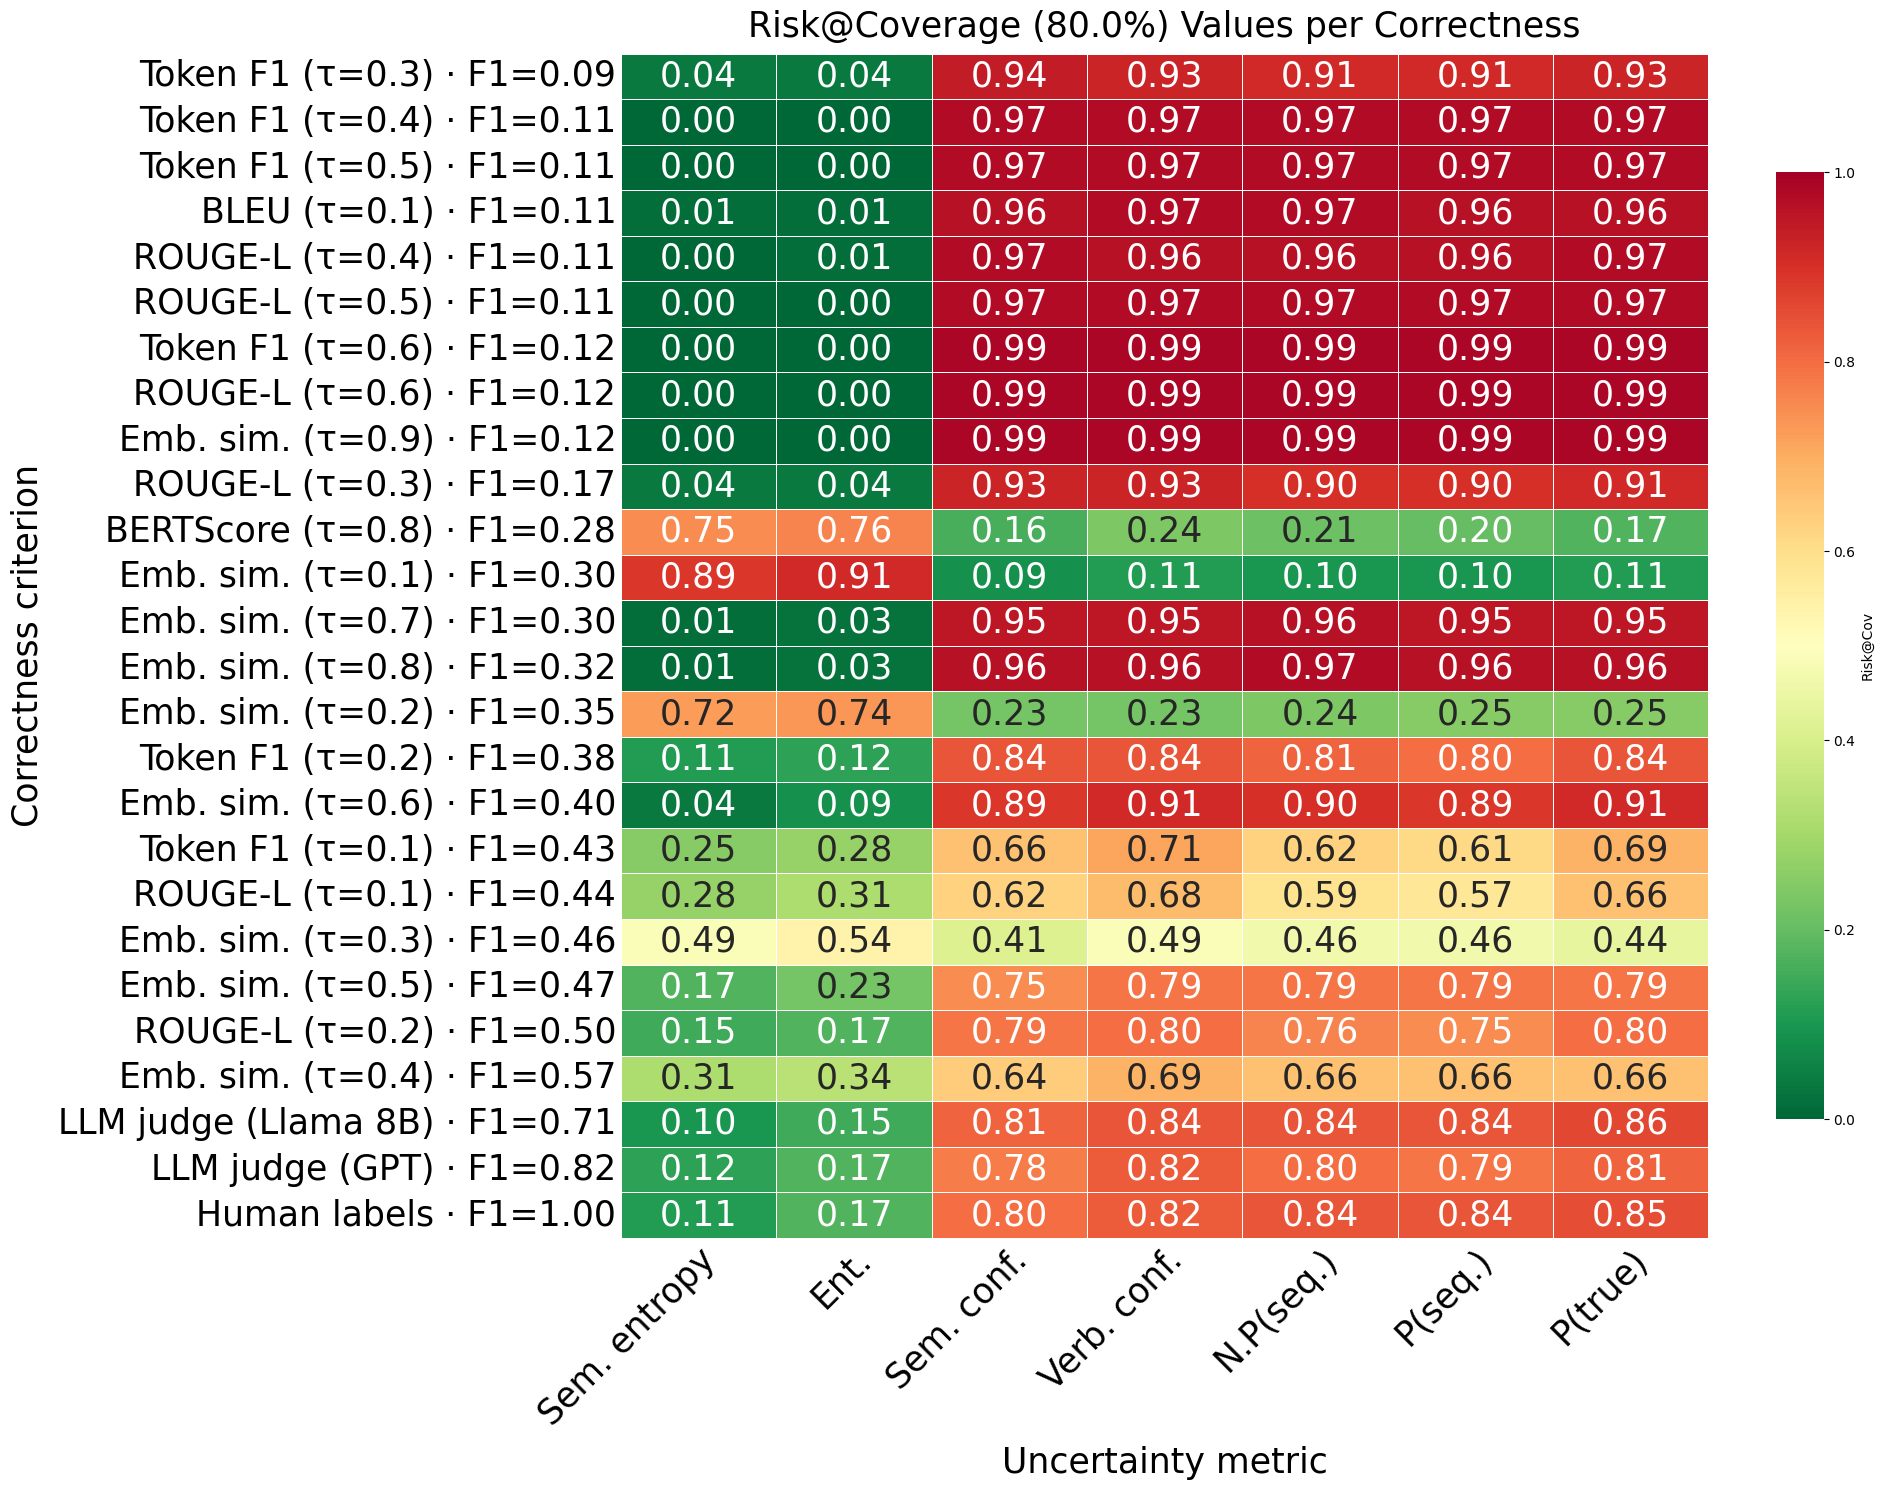

In [ ]:
heatmap_data = auroc_df.pivot(
    index="correctness",
    columns="uncertainty_metric",
    values="auroc"
)
heatmap_data = heatmap_data.reindex(unique_correctness)
sorted_cols = heatmap_data.loc["manual"].sort_values(ascending=True).index
heatmap_data = heatmap_data[sorted_cols]
heatmap_data = label_heatmap_data(heatmap_data)

plt.figure(figsize=(20, 15))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 25},
    cmap="RdYlGn_r",  # 0 = red, 1 = green
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Risk@Cov", "shrink": 0.8},
)

style_heatmap_axes(
    ax,
    xlabel="Uncertainty metric",
    ylabel="Correctness criterion",
    title=f"Risk@Coverage ({target_coverage*100}%) Values per Correctness",
)

plt.tight_layout()
plt.savefig(
    f"/auroc_eval/results/plots/risk_at_coverage_{target_coverage}_values_per_correctness_{model_name}.pdf",
    bbox_inches="tight",
)
plt.show()

In [286]:
# auroc_df[auroc_df["correctness"] == "manual"]

manual_map = (
    auroc_df[auroc_df["correctness"] == "manual"]
    .set_index("uncertainty_metric")["auroc"]
)

auroc_df["auroc_manual"] = auroc_df["uncertainty_metric"].map(manual_map)
auroc_df["auroc_diff"] = auroc_df["auroc"] - auroc_df["auroc_manual"]

In [287]:
auroc_df_filtered = auroc_df[auroc_df["correctness"] != "manual"]

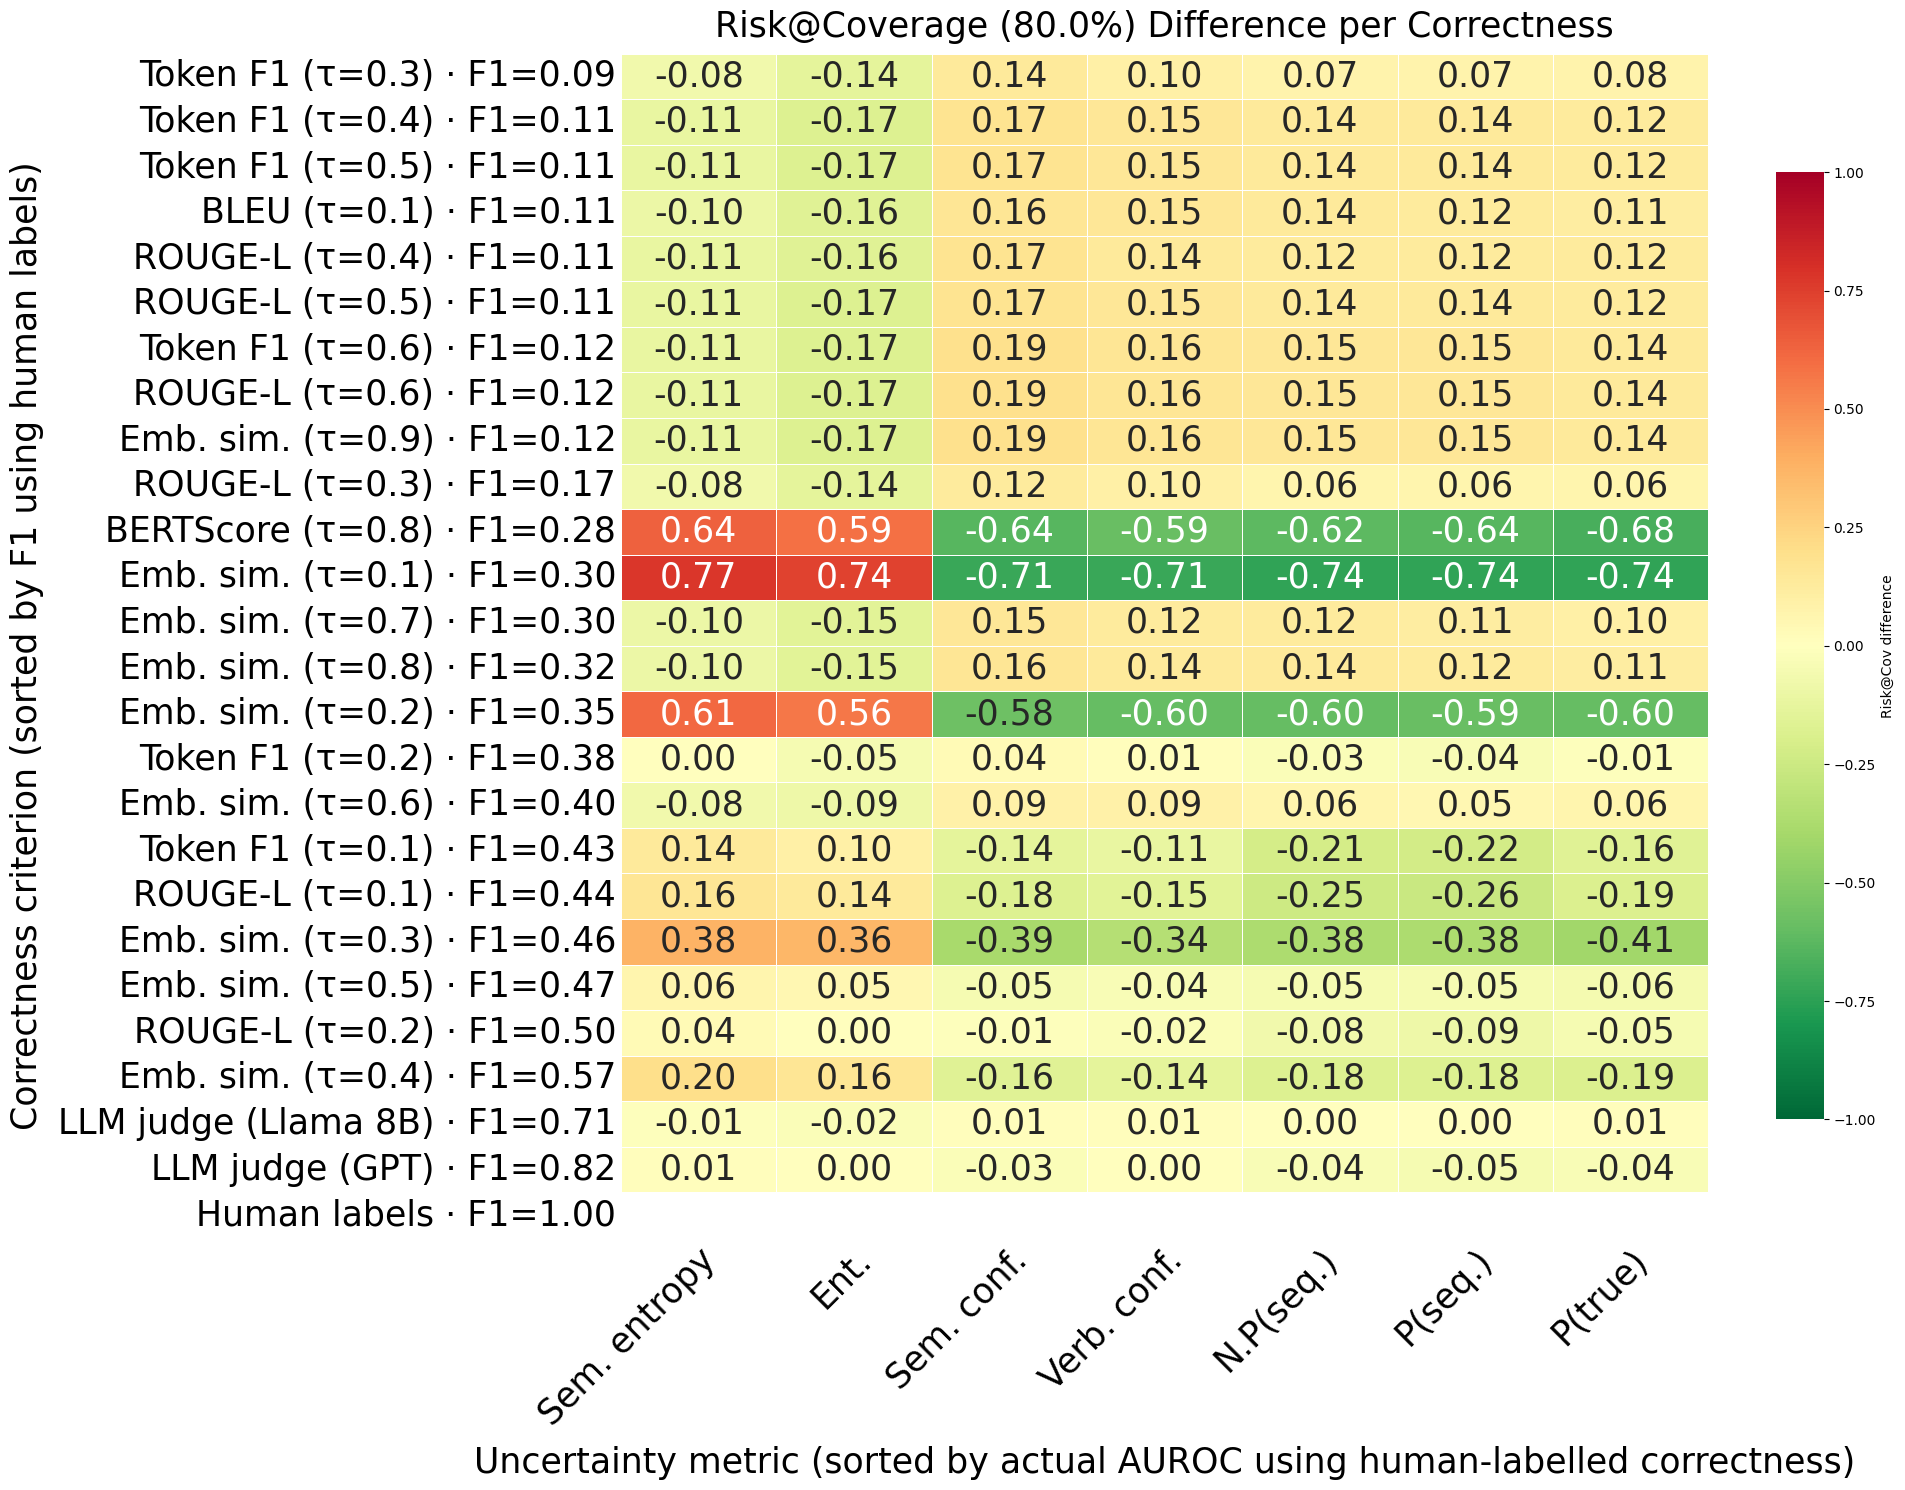

In [ ]:
heatmap_data_diff = auroc_df_filtered.pivot(
    index="correctness",
    columns="uncertainty_metric",
    values="auroc_diff"
)
heatmap_data_diff = heatmap_data_diff.reindex(unique_correctness)
heatmap_data_diff = heatmap_data_diff[sorted_cols]
heatmap_data_diff = label_heatmap_data(heatmap_data_diff)

plt.figure(figsize=(20, 15))

ax = sns.heatmap(
    heatmap_data_diff,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 25},
    cmap="RdYlGn_r",  # -1 = red, 1 = green
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Risk@Cov difference", "shrink": 0.8},
)

style_heatmap_axes(
    ax,
    xlabel="Uncertainty metric (sorted by actual AUROC using human-labelled correctness)",
    ylabel="Correctness criterion (sorted by F1 using human labels)",
    title=f"Risk@Coverage ({target_coverage*100}%) Difference per Correctness",
)

plt.tight_layout()
plt.savefig(
    f"/auroc_eval/results/plots/risk_at_coverage_{target_coverage}_diff_per_correctness_{model_name}.pdf",
    bbox_inches="tight",
)
plt.show()

#### 3) Brier Score

In [289]:
print("Actual brier Scores")
actual_entropy =  brier_score(entropy_scores, [not x for x in correctness_manual])#uncertainty - not confidence -> need to switch correctness sign
actual_semantic_entropy = brier_score(semantic_entropy_scores, [not x for x in correctness_manual])#uncertainty - not confidence -> need to switch correctness sign
actual_semantic_confidence = brier_score(semantic_confidence_scores, correctness_manual)
actual_prob_sequence = brier_score(prob_sequence_scores, correctness_manual)
actual_prob_avg_token = brier_score(prob_avg_token_scores, correctness_manual)
actual_prob_true = brier_score(prob_true_scores, correctness_manual)
actual_verbalised_confidence = brier_score([float(x.replace("Confidence: ", "")) for x in verbalised_confidence_scores], correctness_manual)

Actual brier Scores


In [290]:
if errors == "automated":
    aurocs = {}

    for c in correctness.keys():
        if len(set(correctness[c])) == 1:
            continue
        else:
            aurocs[c] = {} 
            aurocs[c]["metrics"] = {}
            aurocs[c]["metrics"]["acc"] = accuracy_score(correctness_manual, correctness[c])
            aurocs[c]["metrics"]["prec"] = precision_score(correctness_manual, correctness[c])
            aurocs[c]["metrics"]["rec"] = recall_score(correctness_manual, correctness[c])
            aurocs[c]["metrics"]["f1"] = f1_score(correctness_manual, correctness[c])
            aurocs[c]["metrics"]["conf_matrix"] = confusion_matrix(correctness_manual, correctness[c])

            aurocs[c]["uncertainty_metrics"] = {}
            for u in unc_scores.keys():
                if "entropy" in u:
                    aurocs[c]["uncertainty_metrics"][u] = brier_score(unc_scores[u], [not x for x in correctness[c]])
                else:
                    aurocs[c]["uncertainty_metrics"][u] = brier_score(unc_scores[u], correctness[c])
elif errors == "random":
    aurocs = {}
    error_rate = np.arange(0.1, 1, 0.1)


    for e in error_rate:
        switch_indices = np.random.randint(low=0, high=99, size=round(e*100), dtype=int)
        correctness = [abs(1-x)  if i in switch_indices else x for i,x in enumerate(correctness_manual)]
        if len(set(correctness)) == 1:
            continue
        else:
            aurocs["error_rate_"+str(e)[:3]] = {} 
            aurocs["error_rate_"+str(e)[:3]]["metrics"] = {}
            aurocs["error_rate_"+str(e)[:3]]["metrics"]["acc"] = accuracy_score(correctness_manual, correctness)
            aurocs["error_rate_"+str(e)[:3]]["metrics"]["prec"] = precision_score(correctness_manual, correctness)
            aurocs["error_rate_"+str(e)[:3]]["metrics"]["rec"] = recall_score(correctness_manual, correctness)
            aurocs["error_rate_"+str(e)[:3]]["metrics"]["f1"] = f1_score(correctness_manual, correctness)
            aurocs["error_rate_"+str(e)[:3]]["metrics"]["conf_matrix"] = confusion_matrix(correctness_manual, correctness)

            aurocs["error_rate_"+str(e)[:3]]["uncertainty_metrics"] = {}
            for u in unc_scores.keys():
                if "entropy" in u:
                    aurocs["error_rate_"+str(e)[:3]]["uncertainty_metrics"][u] = brier_score(unc_scores[u], [not x for x in correctness])
                else:
                    aurocs["error_rate_"+str(e)[:3]]["uncertainty_metrics"][u] = brier_score(unc_scores[u], correctness)
else:
    raise ValueError("Invalid error type")




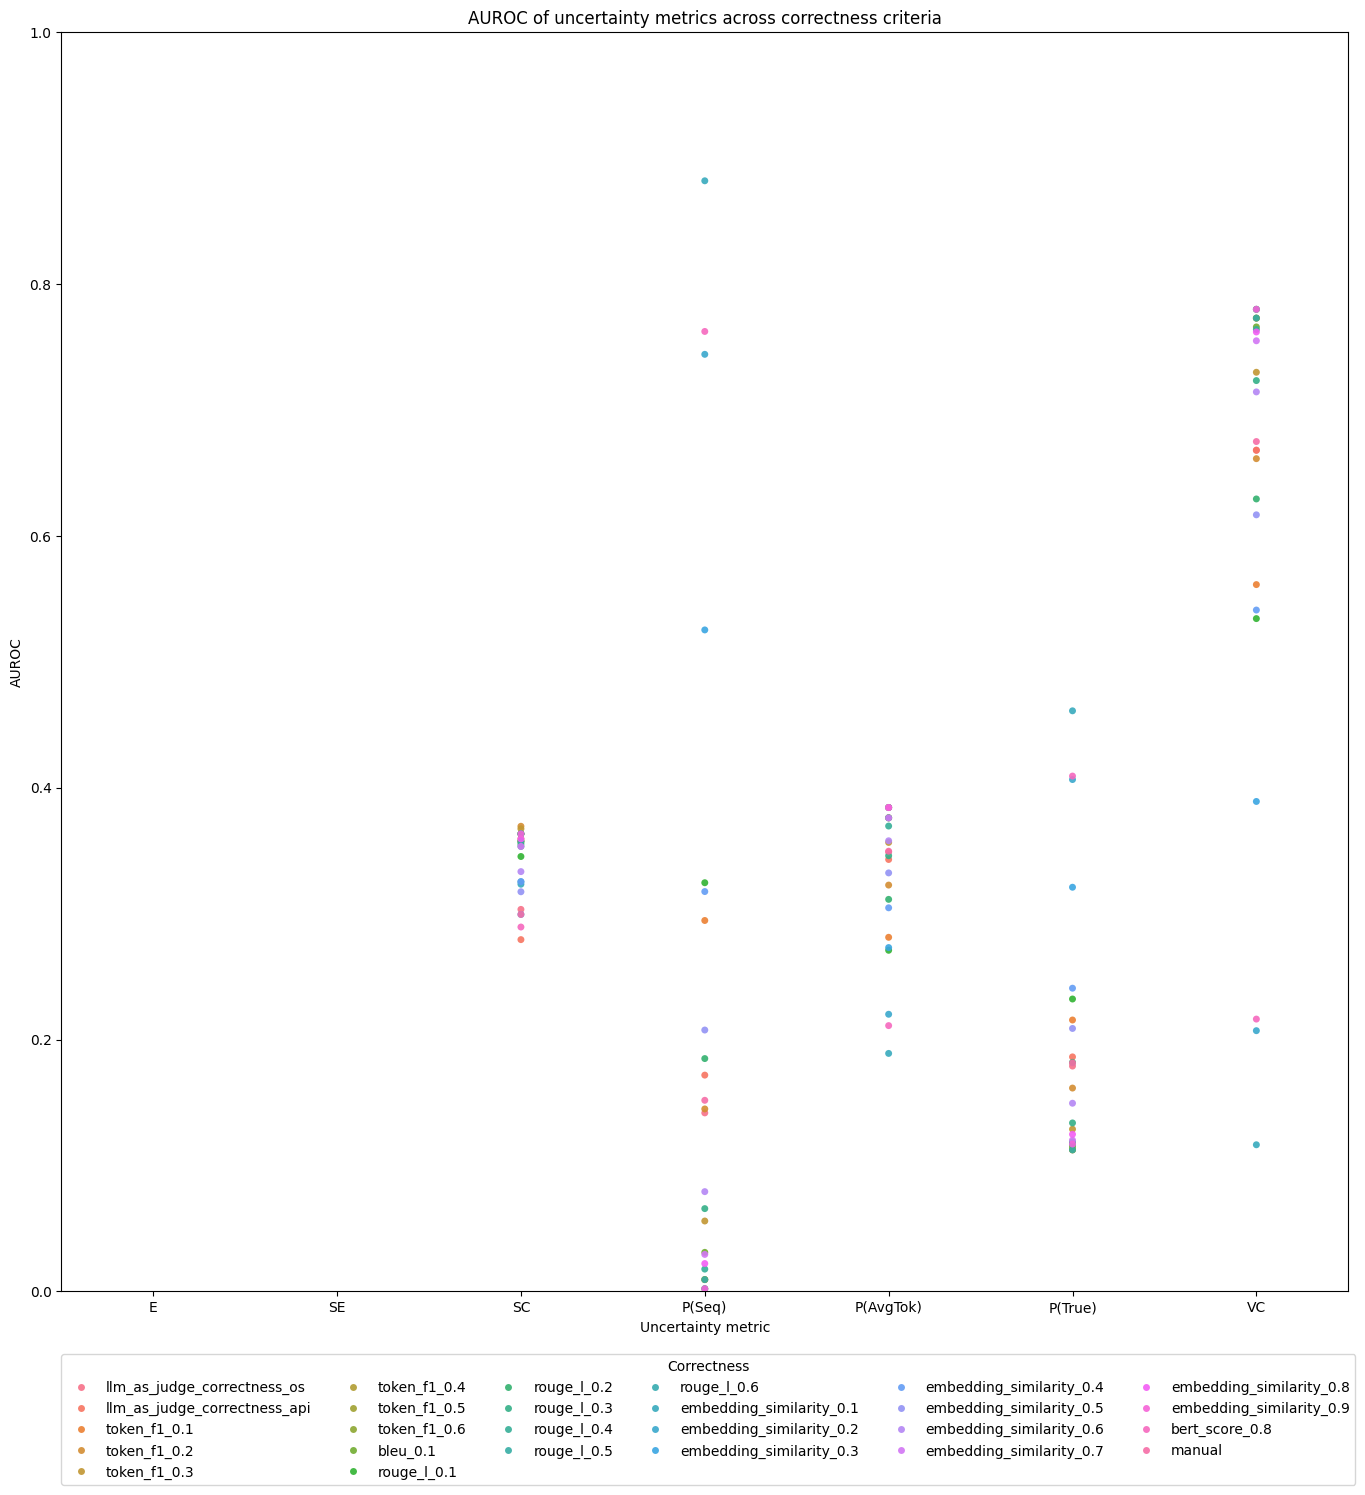

In [291]:
# Visualise AUROC of uncertainty metrics across correctness criteria

rows = []
for correctness_name, values in aurocs.items():
    for unc_name, auroc_val in values["uncertainty_metrics"].items():
        rows.append(
            {
                "correctness": correctness_name,
                "uncertainty_metric": unc_name,
                "auroc": auroc_val,
            }
        )

# Add ACTUAL uncertainty scores based on human-labelled correctness
rows.extend(
    [
        {"correctness": "manual", "uncertainty_metric": "entropy_scores", "auroc": actual_entropy},
        {"correctness": "manual", "uncertainty_metric": "semantic_entropy_scores", "auroc": actual_semantic_entropy},
        {"correctness": "manual", "uncertainty_metric": "semantic_confidence_scores", "auroc": actual_semantic_confidence},
        {"correctness": "manual", "uncertainty_metric": "prob_sequence_scores", "auroc": actual_prob_sequence},
        {"correctness": "manual", "uncertainty_metric": "prob_avg_token_scores", "auroc": actual_prob_avg_token},
        {"correctness": "manual", "uncertainty_metric": "prob_true_scores", "auroc": actual_prob_true},
        {"correctness": "manual", "uncertainty_metric": "verbalised_confidence_scores", "auroc": actual_verbalised_confidence},
    ]
)

auroc_df = pd.DataFrame(rows)

plt.figure(figsize=(15, 15))
# Use dots on the same vertical line for each uncertainty metric
sns.stripplot(
    data=auroc_df,
    x="uncertainty_metric",
    y="auroc",
    hue="correctness",
    dodge=False,  # all on same vertical line
    jitter=False,
    alpha=0.9,
)


# Move legend outside and make it 4 columns
plt.legend(
    title="Correctness",
    bbox_to_anchor=(0.0, -0.05),
    loc="upper left",
    borderaxespad=0.0,
    ncol=6,
)

# plt.xticks(rotation=0, ticks=["E", "SE", "SC", "P(Seq)", "P(AvgTok)", "P(True)", "VC"])
plt.gca().set_xticks(ticks=range(7), labels=["E", "SE", "SC", "P(Seq)", "P(AvgTok)", "P(True)", "VC"])
plt.ylim(0, 1)
plt.xlabel("Uncertainty metric")
plt.ylabel("AUROC")
plt.title("AUROC of uncertainty metrics across correctness criteria")
plt.tight_layout()
plt.show()

In [292]:
bins = np.linspace(0, 1, 11)
bins_f1 = {}
for k in aurocs.keys():
    f1 = aurocs[k]["metrics"]["f1"]
    f1_bin = math.floor(f1 * 10) / 10
    try:
        bins_f1[f"{f1_bin}-{f1_bin+0.1}"].append(k)
    except:
        bins_f1[f"{f1_bin}-{f1_bin+0.1}"] = [k]

visual_correctness_criteria = []
for k in bins_f1.keys():
    visual_correctness_criteria.append(random.sample(bins_f1[k], 1)[0])

In [293]:
filtered_aurocs = {}
for k in aurocs.keys():
    if k in visual_correctness_criteria:
        filtered_aurocs[k] = aurocs[k]

In [294]:
unique_correctness = auroc_df["correctness"].unique()

dict_f1_filtered = {}
pairs = []
for corr in unique_correctness:
    if corr == "manual":
        dict_f1_filtered[corr] = 1
        pairs.append((corr, 1))
    else:
        dict_f1_filtered[corr] = round(aurocs[corr]["metrics"]["f1"],2)
        pairs.append((corr, round(aurocs[corr]["metrics"]["f1"],2)))

In [295]:
pairs.sort(key=lambda x: x[1], reverse=False)

In [296]:
unique_correctness = np.array([x[0] for x in pairs])

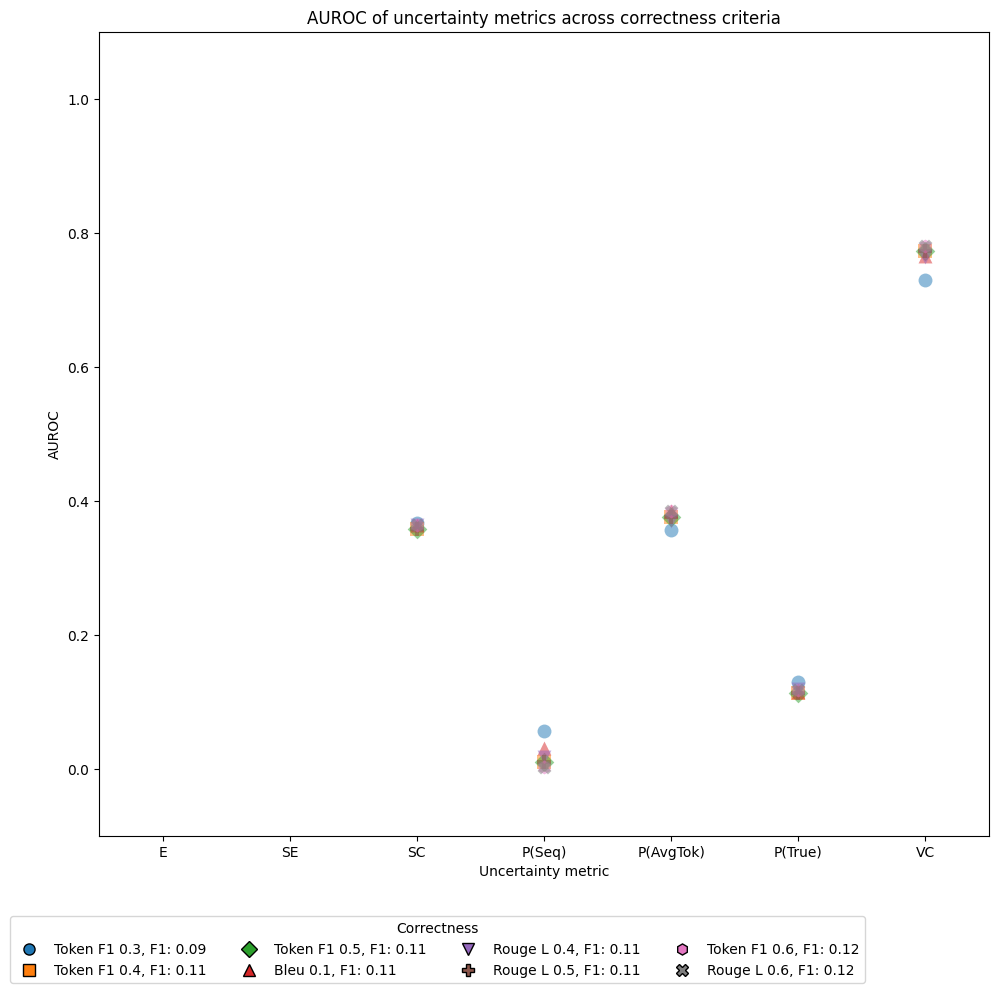

In [297]:
plt.figure(figsize=(10, 10))

# Define a marker for each correctness criterion
markers = ["o", "s", "D", "^", "v", "P", "h", "X"]  # extend if you have more groups
# unique_correctness = auroc_df["correctness"].unique()

for marker, corr in zip(markers, unique_correctness):
    subset = auroc_df[auroc_df["correctness"] == corr]
    if corr == "manual":
        sns.stripplot(
        data=subset,
        x="uncertainty_metric",
        y="auroc",
        label=f"{' '.join(corr.split('_')).title()}",
        dodge=True,
        jitter=True,
        alpha=0.5,
        marker=marker,
        size=25
    )
    else:
        sns.stripplot(
        data=subset,
        x="uncertainty_metric",
        y="auroc",
        label=f"{' '.join(corr.split('_')).title()}",
        dodge=False,
        jitter=False,
        alpha=0.5,
        marker=marker,
        size=10)

plt.ylim(-0.1, 1.1)
plt.xlabel("Uncertainty metric")
plt.ylabel("AUROC")
plt.title("AUROC of uncertainty metrics across correctness criteria")

from matplotlib.lines import Line2D
import seaborn as sns

# Same palette order as seaborn uses for the plot
palette = sns.color_palette(n_colors=len(unique_correctness))

legend_elements = [
    Line2D(
        [0],
        [0],
        marker=marker,
        color="none",
        markerfacecolor=color,
        markeredgecolor="black",
        markersize=8,
        linestyle="None",
        label=f"{' '.join(corr.split('_')).title()}, F1: {dict_f1_filtered[corr]}",
    )
    for (marker, corr), color in zip(zip(markers, unique_correctness), palette)
]

plt.legend(
    handles=legend_elements,
    title="Correctness",
    bbox_to_anchor=(-0.1, -0.1),
    loc="upper left",
    borderaxespad=0.0,
    ncol=4
)

plt.gca().set_xticks(ticks=range(7), labels=["E", "SE", "SC", "P(Seq)", "P(AvgTok)", "P(True)", "VC"], rotation=0)

plt.tight_layout()
plt.show()

In [298]:
auroc_df["auroc_rank"] = (
    auroc_df.groupby("correctness")["auroc"]
      .rank(method="first", ascending=True)
      .astype(int)
)

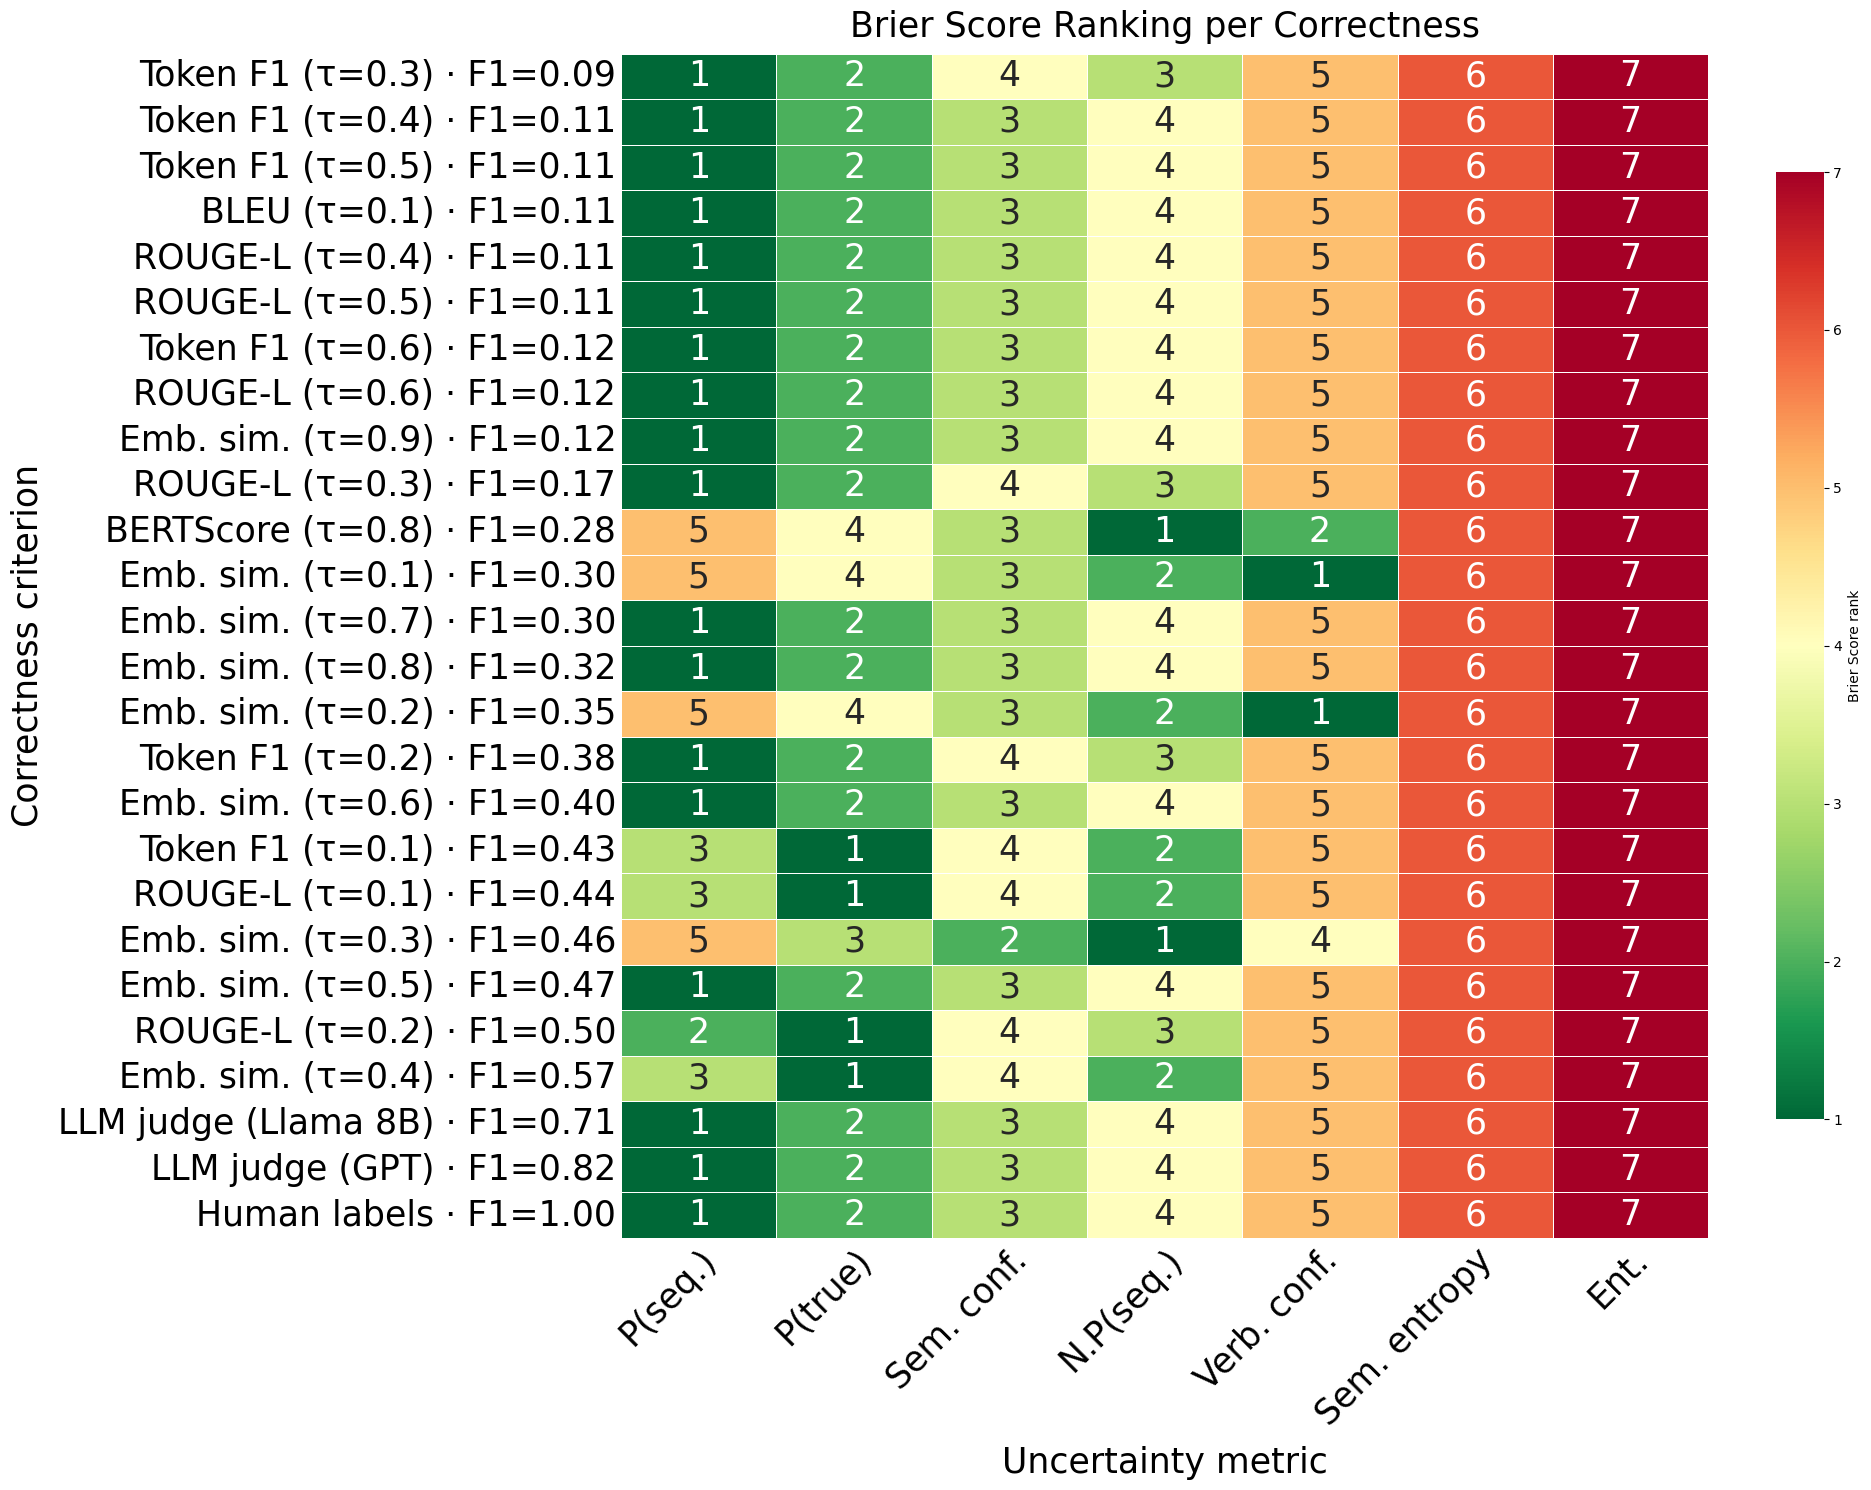

In [ ]:
heatmap_data = auroc_df.pivot(
    index="correctness",
    columns="uncertainty_metric",
    values="auroc_rank"
)
heatmap_data = heatmap_data.reindex(unique_correctness)
sorted_cols = heatmap_data.loc["manual"].sort_values().index
heatmap_data = heatmap_data[sorted_cols]
heatmap_data = label_heatmap_data(heatmap_data)

plt.figure(figsize=(20, 15))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    annot_kws={"size": 25},
    cmap="RdYlGn_r",  # rank 1 = green, rank 7 = red
    vmin=1,
    vmax=7,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Brier Score rank", "shrink": 0.8},
)

style_heatmap_axes(
    ax,
    xlabel="Uncertainty metric",
    ylabel="Correctness criterion",
    title="Brier Score Ranking per Correctness",
)

plt.tight_layout()
plt.savefig(
    f"/auroc_eval/results/plots/brier_score_ranking_per_correctness_{model_name}.pdf",
    bbox_inches="tight",
)
plt.show()

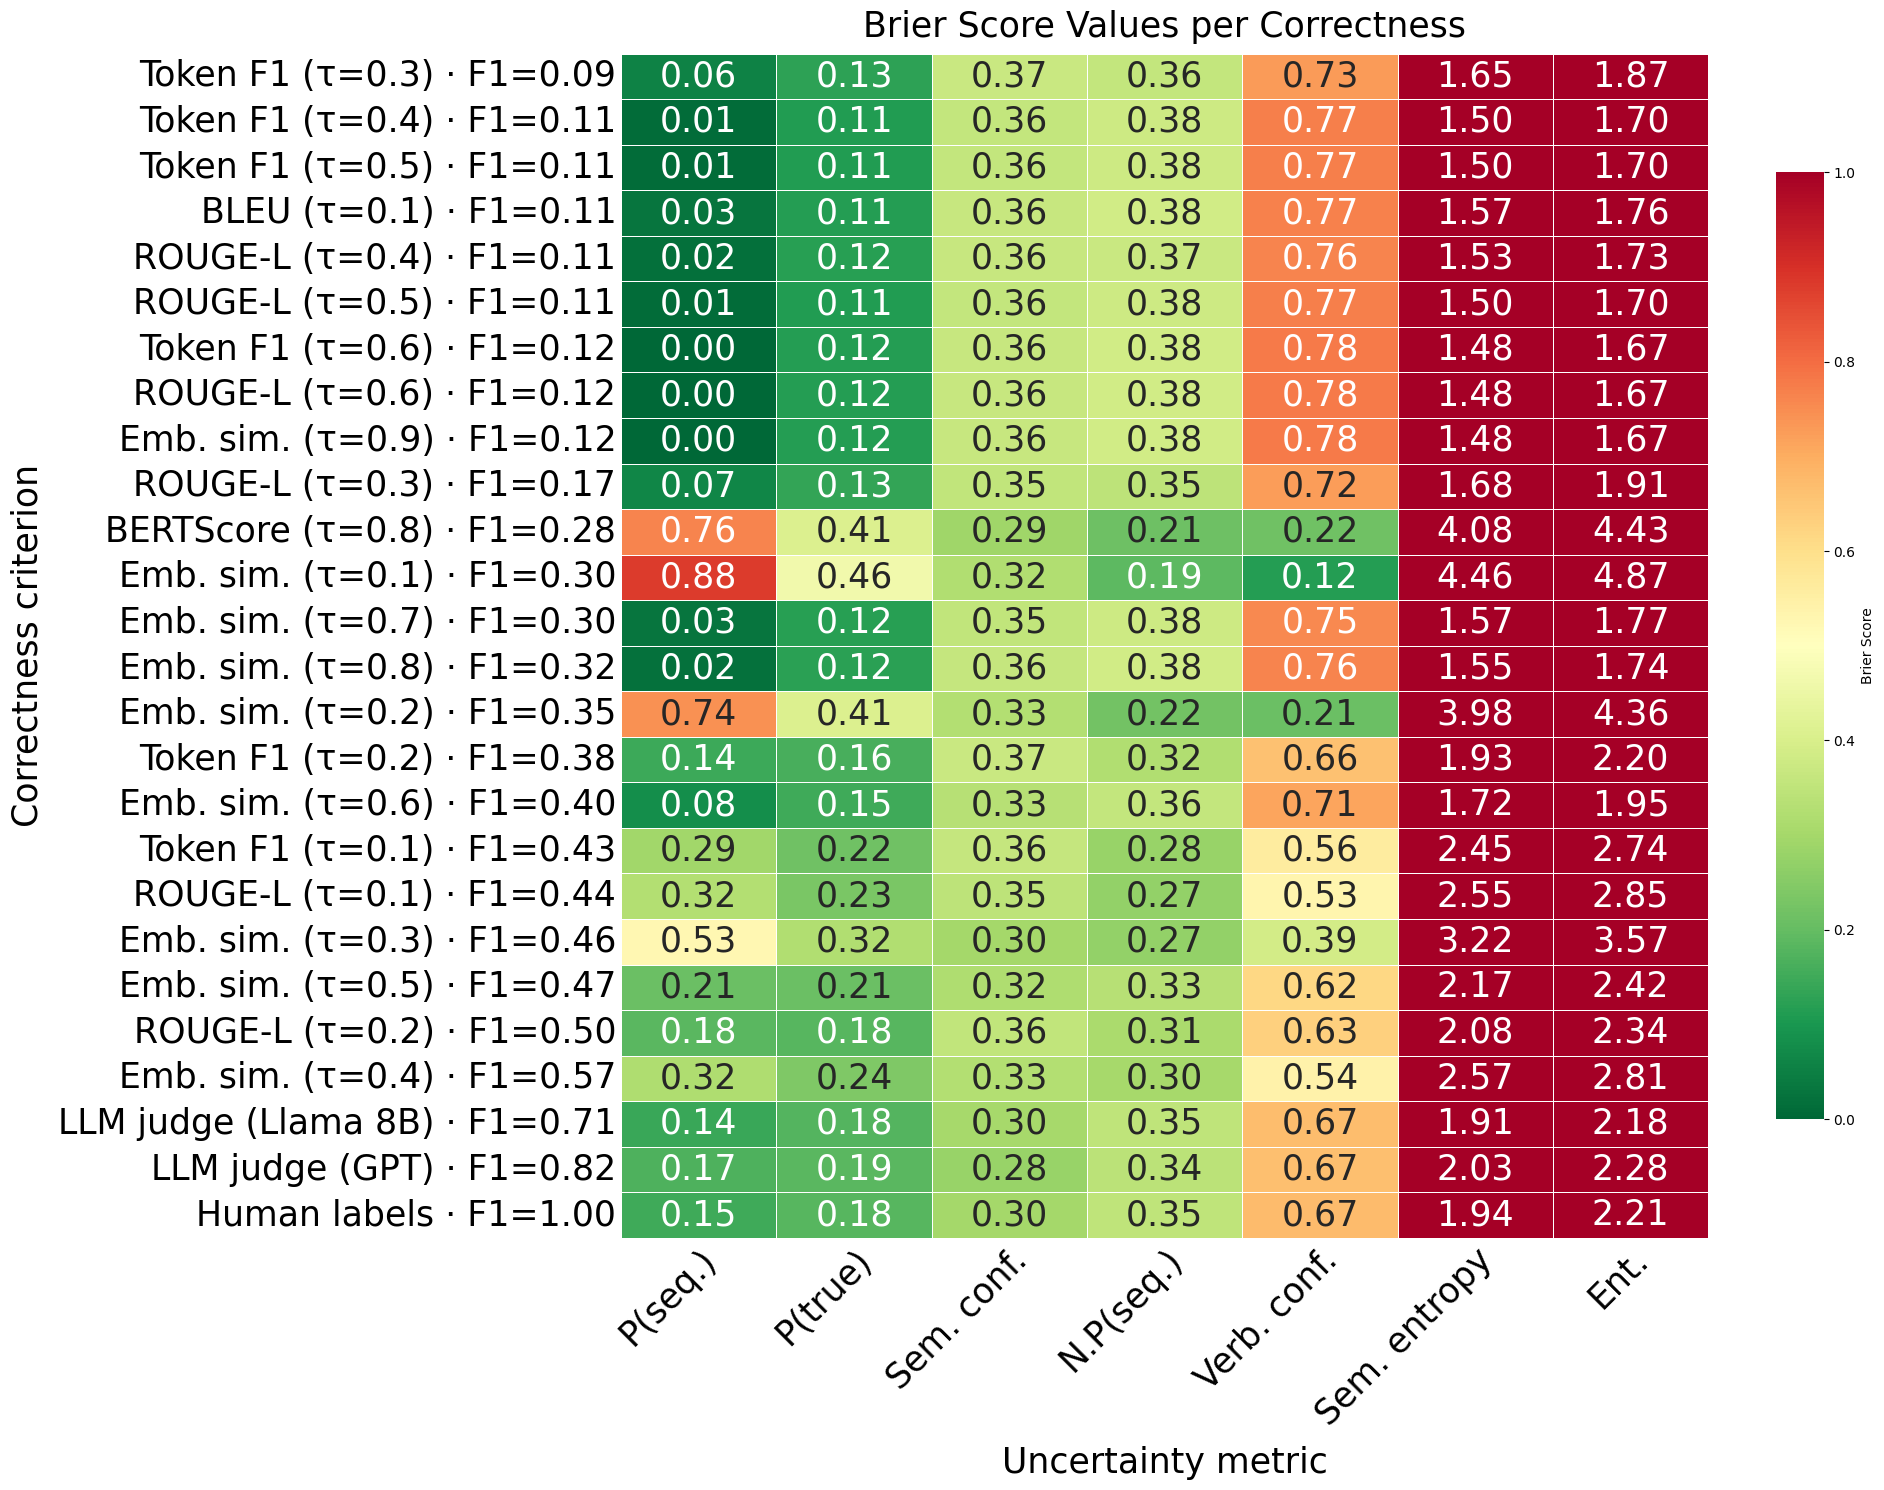

In [ ]:
heatmap_data = auroc_df.pivot(
    index="correctness",
    columns="uncertainty_metric",
    values="auroc"
)
heatmap_data = heatmap_data.reindex(unique_correctness)
sorted_cols = heatmap_data.loc["manual"].sort_values(ascending=True).index
heatmap_data = heatmap_data[sorted_cols]
heatmap_data = label_heatmap_data(heatmap_data)

plt.figure(figsize=(20, 15))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 25},
    cmap="RdYlGn_r",  # 0 = red, 1 = green
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Brier Score", "shrink": 0.8},
)

style_heatmap_axes(
    ax,
    xlabel="Uncertainty metric",
    ylabel="Correctness criterion",
    title="Brier Score Values per Correctness",
)

plt.tight_layout()
plt.savefig(
    f"/auroc_eval/results/plots/brier_score_values_per_correctness_{model_name}.pdf",
    bbox_inches="tight",
)
plt.show()

In [301]:
# auroc_df[auroc_df["correctness"] == "manual"]

manual_map = (
    auroc_df[auroc_df["correctness"] == "manual"]
    .set_index("uncertainty_metric")["auroc"]
)

auroc_df["auroc_manual"] = auroc_df["uncertainty_metric"].map(manual_map)
auroc_df["auroc_diff"] = auroc_df["auroc"] - auroc_df["auroc_manual"]

In [302]:
auroc_df_filtered = auroc_df[auroc_df["correctness"] != "manual"]

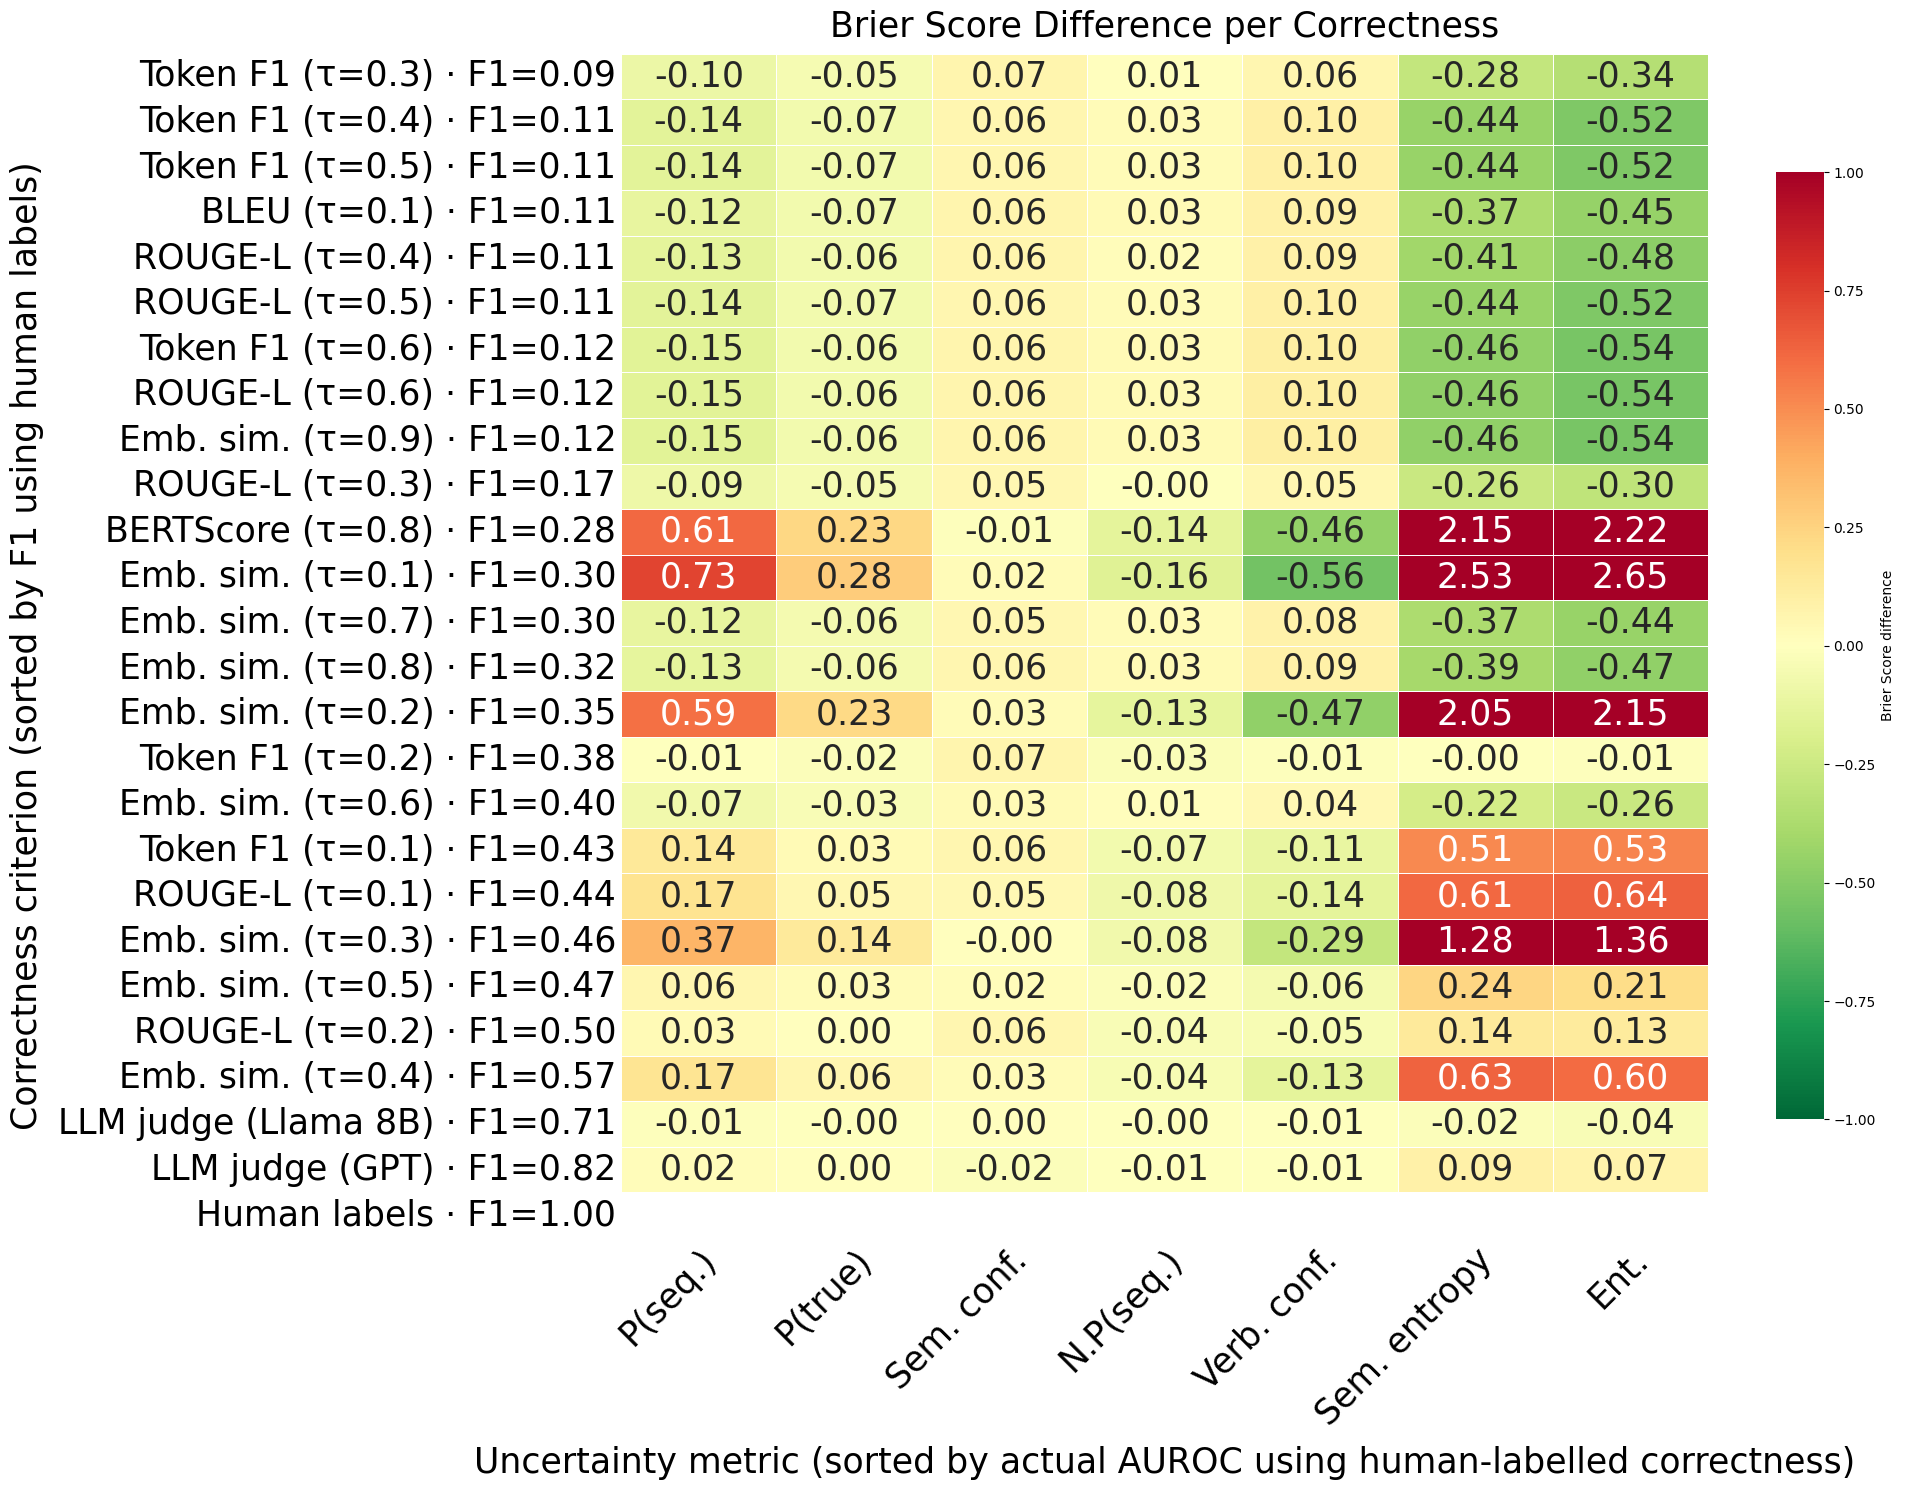

In [ ]:
heatmap_data_diff = auroc_df_filtered.pivot(
    index="correctness",
    columns="uncertainty_metric",
    values="auroc_diff"
)
heatmap_data_diff = heatmap_data_diff.reindex(unique_correctness)
heatmap_data_diff = heatmap_data_diff[sorted_cols]
heatmap_data_diff = label_heatmap_data(heatmap_data_diff)

plt.figure(figsize=(20, 15))

ax = sns.heatmap(
    heatmap_data_diff,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 25},
    cmap="RdYlGn_r",  # -1 = red, 1 = green
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Brier Score difference", "shrink": 0.8},
)

style_heatmap_axes(
    ax,
    xlabel="Uncertainty metric (sorted by actual AUROC using human-labelled correctness)",
    ylabel="Correctness criterion (sorted by F1 using human labels)",
    title="Brier Score Difference per Correctness",
)

plt.tight_layout()
plt.savefig(
    f"/auroc_eval/results/plots/brier_score_diff_per_correctness_{model_name}.pdf",
    bbox_inches="tight",
)
plt.show()